# Sherwood Webb et al. 2020 model — UL and US baselines

Minimal driver for [`SherwoodWebb.stan`](SherwoodWebb.stan): runs both the UL (uniform-$\lambda$) and
US (uniform-$S$) baselines and compares the marginal posterior of $S$ to Sherwood Table 10.

*Notes*: 
- More information can be found in the Readme.md file in the repo
- The model has one minor difference from Sherwood Webb et al, in that it does not account for correlations between historical forcing $F_{hist}$ and $F_{2\times\text{CO}_2}$. Yet.  
- To do: 
  - add in diagnostics plot for the HMC sampler (prior/posterior predictive checks, divergence plots, etc)
  - reproduce the rest of Sherwood Webb et al Table 10. 

In [1]:
import os
import logging
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import cmdstanpy

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

ROOT = Path(os.getcwd())
assert (ROOT / 'SherwoodWebb.stan').exists(), f'stan fie not found in {ROOT}'
assert (ROOT / 'Cooper_SW20.stan').exists(), f'stan fie not found in {ROOT}'

## Sherwood baseline values

Process: aggregate of 11 Gaussian feedback components (Table 1).
Historical: Table 5 BASELINE row.  Paleo: Tables 7 (LGM) and 8 (mPWP).

The only difference between the UL and US data files is the integer flag
`use_uniform_lambda_prior`.

In [2]:
# INPUT PARAMETER BLOCK

# -------------Posterior sample size-------------
N_CHAINS=4
N_WARMUP=5000
N_SAMPLES=125000

#Timing: ~ 1 sec / 10,000 samples with 4 chains
# e.g. 520,000 samples (N=4 chains)x(5000 warmups + 125,000 samples) takes ~50 seconds

#scaling between 5-95 percentiles and sigma for a gaussian:
PCT = 1.645   # 5/95 -> 1.645 sigma

#-------------Baseline values from Sherwood (pyCmndStan takes in data as a dictionary)-------------
SW20_BASE = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    'mu_zeta':         0.06, 'sig_zeta':        0.20,
    # -------------Process-------------
    'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    # -------------Historical-------------
    'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    'mu_F_hist':       1.83,
    'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':       3.0,  'sig_T_plio':      1.0,
    'mu_CO2_plio':     375.0,'sig_CO2_plio':    25.0,
    'mu_fCH4':         0.4,  'sig_fCH4':        0.1,
    'mu_fESS':         0.5,  'sig_fESS':        0.25,
}

# flag for choosing uniform lambda or uniform S
sw20_data_UL = dict(SW20_BASE, use_uniform_lambda_prior=1)
sw20_data_US = dict(SW20_BASE, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
init = dict(S=3.0, F_2xCO2=4.0, zeta=0.06,
            F_z=0.0, N_hist=0.6, dlambda=0.5,
            T_LGM=-5.0, alpha=0.1,
            CO2_plio=375.0, fCH4=0.4, fESS=0.5)

# Sherwood Table 10 reference values: (P5, P17, P50, P83, P95, mean)
SHERWOOD_UL = (2.3, 2.6, 3.1, 3.9, 4.7, 3.2)
SHERWOOD_US = (2.4, 2.8, 3.5, 4.5, 5.7, 3.7)

## Cooper update

## Revised Historical Likelihood

```stan
// Historical
F_z     ~ std_normal();
T_hist  ~ normal(mu_T_hist, sig_T_hist);
N_hist  ~ normal(mu_N_hist, sig_N_hist);
dlambda ~ normal(mu_dlambda, sig_dlambda);
```

Statistically, this corresponds to:

$$
T_{\mathrm{hist,true}} \sim \mathcal{N}
\left(\mu_{T,\mathrm{hist}}, \sigma_{T,\mathrm{hist}}\right)
$$

$$
N_{\mathrm{hist,true}} =
F_{\mathrm{hist}} +
T_{\mathrm{hist,true}}\left(\lambda - \Delta\lambda\right)
$$

$$
N_{\mathrm{hist,obs}} \sim \mathcal{N}
\left(N_{\mathrm{hist,true}}, \sigma_{N,\mathrm{hist}}\right)
$$

where `T_hist` is treated as a latent historical warming state and `N_hist` is the budget-implied TOA imbalance.

In [3]:
# INPUT PARAMETER BLOCK
#-------------Baseline values (pyCmndStan takes in data as a dictionary)-------------
coop_BASE = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       4.0,  'sig_F2xCO2':      0.3,
    'mu_zeta':         0.06, 'sig_zeta':        0.20,
    # -------------Process-------------
    'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    # -------------Historical-------------
    'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    'mu_F_hist':       1.83,
    'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':       3.0,  'sig_T_plio':      1.0,
    'mu_CO2_plio':     375.0,'sig_CO2_plio':    25.0,
    'mu_fCH4':         0.4,  'sig_fCH4':        0.1,
    'mu_fESS':         0.5,  'sig_fESS':        0.25,
}

# flag for choosing uniform lambda or uniform S
coop_data_UL = dict(coop_BASE, use_uniform_lambda_prior=1)
coop_data_US = dict(coop_BASE, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
init = dict(S=3.0, F_2xCO2=4.0, zeta=0.06,
            F_z=0.0, N_hist=0.6, dlambda=0.5,
            T_LGM=-5.0, alpha=0.1,
            CO2_plio=375.0, fCH4=0.4, fESS=0.5)

In [4]:
# INPUT PARAMETER BLOCK
#-------------REVISED values (pyCmndStan takes in data as a dictionary)-------------
coop_REVISED = {
    # -------------Shared-parameters-------------
    'mu_F2xCO2':       3.93,  'sig_F2xCO2':      0.29, #0.4716 / PCT
    
    'mu_zeta':         0.00, 'sig_zeta':        0.0001, # make zero bc incl. in dlamb
    # 'mu_zeta':         0.06, 'sig_zeta':        0.20, # check lewis
    # "rho_dlambda_LGM_plio": 0.56, ## correlation of paleo pattern effect
    "rho_dlambda_LGM_plio": 0.7, ## correlation of paleo pattern effect
    # "rho_dlambda_LGM_plio": 0.87, ## correlation of paleo pattern effect, if using 4xCO2
    
    # -------------Process-------------
    'mu_lambda':      -0.92, 'sig_lambda':      0.35,
    # 'mu_lambda':      -1.30, 'sig_lambda':      0.44,
    
    # -------------Historical-------------
    # 'mu_T_hist':       1.13, 'sig_T_hist':     np.sqrt(0.100**2+0.07**2), #C25 through 2023
    'mu_T_hist':       1.08, 'sig_T_hist':     np.sqrt(0.084**2+0.07**2), #Thorne through 2024
    'mu_N_hist':       0.71,  'sig_N_hist':    0.20,
    'mu_F_hist':       2.65,
    'sig_F_hist':      0.41,
    'mu_dlambda':      0.62,  'sig_dlambda':    0.33, ## too high bc ignores skew left
    
    # 'mu_T_hist':       1.03, 'sig_T_hist':     (1.03 - 0.89) / PCT,
    # 'mu_N_hist':       0.6,  'sig_N_hist':     (0.6 - 0.3)   / PCT,
    # 'mu_F_hist':       1.83,
    # 'sig_F_hist_low': (1.83 - (-0.03)) / PCT,
    # 'sig_F_hist_high':(2.71 - 1.83)    / PCT,
    # 'mu_dlambda':      0.5,  'sig_dlambda':    (0.5 - 0.0)   / PCT,
    # -------------LGM-------------
    'mu_T_LGM':        -6.0, 'sig_T_LGM':        1.0,
    # 'mu_F_other_LGM':  -5.1, 'sig_F_other_LGM':  2.1,
    'mu_F_other_LGM':  -4.5, 'sig_F_other_LGM':  2.1,
    'mu_N_LGM':         0.0,  'sig_N_LGM':       0.1/1.645, ## placeholder budget residual
    # 'mu_dlambda_LGM':  -0.37,'sig_dlambda_LGM':  0.23*1.5,
    'mu_dlambda_LGM': -0.42,'sig_dlambda_LGM':  0.34*1.,
    
    # 'mu_T_LGM':       -5.0,  'sig_T_LGM':       1.0,
    # 'mu_F_LGM':       -6.15, 'sig_F_LGM':       2.0,
    # 'mu_alpha':        0.1,  'sig_alpha':       0.1,
    # ------------Pliocene-mPWP-------------
    'mu_T_plio':        4.1,  'sig_T_plio':        0.6,
    'mu_CO2_plio':      367.0,'sig_CO2_plio':      30.0, #mPWP
    # 'mu_CO2_plio':      375.0,'sig_CO2_plio':      25.0, #mPWP # Sherwood
    # 'mu_CO2_plio':      391.0,'sig_CO2_plio':      15.0, #KM5c
    'mu_fCH4':          0.43,  'sig_fCH4':          0.08, # biased low, missing right skew
    'mu_F_plio_nonGHG': 1.76,   'sig_F_plio_nonGHG':  1.0, #added aerosol unc of 1.46/2 Wm-2
    'mu_N_plio':        0.0,   'sig_N_plio':        0.1/1.645, ## placeholder budget residual
    # 'mu_dlambda_plio': -0.37,'sig_dlambda_plio':  0.32*1.,
    'mu_dlambda_plio': -0.44,'sig_dlambda_plio':  0.40*1.,
    
    # 'mu_fESS':          0.5,  'sig_fESS':          0.25,
}

# flag for choosing uniform lambda or uniform S
coopREV_data_UL = dict(coop_REVISED, use_uniform_lambda_prior=1)
coopREV_data_US = dict(coop_REVISED, use_uniform_lambda_prior=0)

#initial guesses for the HMC samper
initREV = dict(
    S=3.0,
    F_2xCO2=3.93,
    zeta=0.,

    F_hist=2.65,
    T_hist=1.08,
    dlambda=0.62,

    T_LGM=-6.0,
    F_other_LGM=-5.1,
    dlambda_LGM=-0.4,
    N_LGM=0.0,
    
    T_plio=4.1,
    CO2_plio=367.0,
    F_plio_nonGHG=1.76,
    N_plio=0.0,
    
    dlambda_plio=-0.4,
    fCH4=0.4,
)

## Compile the model

In [5]:
model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'SherwoodWebb.stan'))
print('binary:', model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/SherwoodWebb


In [6]:
## SW20 values with Cooper equations and Historical adjusted
coop_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_SW20.stan'))
print('binary:', coop_model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_SW20


In [7]:
## Cooper values and equations with SW20 method of T on LHS
coopREV_model = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_revised-correlated.stan'))
print('binary:', coopREV_model.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_revised-correlated


In [8]:
## Cooper values and equations with additional N term for paleo and N on LHS
coopREV_model_Nresid = cmdstanpy.CmdStanModel(stan_file=str(ROOT / 'Cooper_rev_corr_Nresid.stan'))
print('binary:', coopREV_model_Nresid.exe_file)

binary: /glade/derecho/scratch/vcooper/projects/bayecs/Cooper_rev_corr_Nresid


## Sample both US and UL baselines

Note: adapt_delta=0.95 reduces the number of divergences. This is probably due to the shape of posterior when $\lambda-\Delta \lambda=0$, since it the number of divergences started increasing when the pattern effect term was added to the historical likelihood


In [9]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
sw20_json_UL = '/tmp/bayecs_sw20_baseline_UL.json'
sw20_json_US = '/tmp/bayecs_sw20_baseline_US.json'
cmdstanpy.write_stan_json(sw20_json_UL, sw20_data_UL)
cmdstanpy.write_stan_json(sw20_json_US, sw20_data_US)

common = dict(inits=init, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=True,
              show_console=False, refresh=999999)

sw20_fit_UL = model.sample(data=sw20_json_UL, **common)
sw20_fit_US = model.sample(data=sw20_json_US, **common)

sw20_S_UL = sw20_fit_UL.draws_xr(vars=['S']).S.values.ravel()
sw20_S_US = sw20_fit_US.draws_xr(vars=['S']).S.values.ravel()

17:05:26 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:06:36 - cmdstanpy - INFO - CmdStan done processing.


17:06:48 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 9 divergent transitions (0.0%)
	Chain 2 had 3 divergent transitions (0.0%)
	Chain 3 had 43 divergent transitions (0.0%)
	Chain 4 had 32 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


## Summary

In [10]:
def line(label, S, fit, sherwood):
    p5, p17, p50, p83, p95 = np.percentile(S, [5, 17, 50, 83, 95])
    div = int(np.sum(fit.method_variables()['divergent__']))
    print(f'=== {label} ===')
    print(f'  n_draws       : {len(S)}')
    print(f'  mean +/- std  : {S.mean():.2f} +/- {S.std():.2f}')
    print(f'  divergences   : {div}')
    print()
    print(f'  First row: Sherwood Table 10 reference ({label}):')
    print(f'  Second row: Stan estimate ({label}):')
    print(f'    P5  P17  P50  P83  P95   mean')
    print(f'    {sherwood[0]:.2f} {sherwood[1]:.2f}  {sherwood[2]:.2f} {sherwood[3]:.2f}  {sherwood[4]:.2f}   {sherwood[5]:.2f}')
    print(f'    {p5:.2f} {p17:.2f}  {p50:.2f} {p83:.2f}  {p95:.2f}   {S.mean():.2f}')
    print()

In [11]:
line('UL baseline', sw20_S_UL, sw20_fit_UL, SHERWOOD_UL)
line('US baseline', sw20_S_US, sw20_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.27 +/- 0.82
  divergences   : 332

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.22 2.55  3.13 3.95  4.77   3.27

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.70 +/- 1.08
  divergences   : 87

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.41 2.79  3.50 4.53  5.66   3.70



## Plot

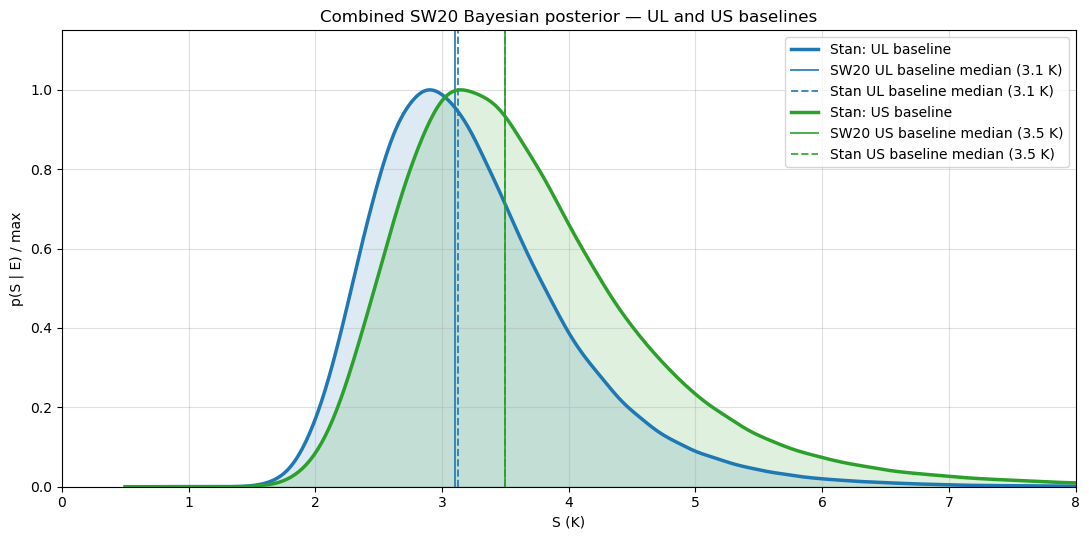

In [12]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(sw20_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (sw20_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid); pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

# coop version

### Revised historical structure only

In [13]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
coop_json_UL = '/tmp/bayecs_cooper_baseline_UL.json'
coop_json_US = '/tmp/bayecs_cooper_baseline_US.json'
cmdstanpy.write_stan_json(coop_json_UL, coop_data_UL)
cmdstanpy.write_stan_json(coop_json_US, coop_data_US)

common = dict(inits=init, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=True,
              show_console=False, refresh=5000)

coop_fit_UL = coop_model.sample(data=coop_json_UL, **common)
coop_fit_US = coop_model.sample(data=coop_json_US, **common)

coop_S_UL = coop_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coop_S_US = coop_fit_US.draws_xr(vars=['S']).S.values.ravel()

17:06:58 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:07:46 - cmdstanpy - INFO - CmdStan done processing.
17:07:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Exception: normal_lpdf: Random variable is nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_SW20.stan', line 195, column 4 to column 45)
Consider re-running with show_console=True if the above output is unclear!


17:07:58 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [14]:
line('UL baseline', coop_S_UL, coop_fit_UL, SHERWOOD_UL)
line('US baseline', coop_S_US, coop_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.36 +/- 0.87
  divergences   : 0

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.27 2.61  3.21 4.08  4.95   3.36

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.16
  divergences   : 1

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.47 2.87  3.62 4.73  5.95   3.84



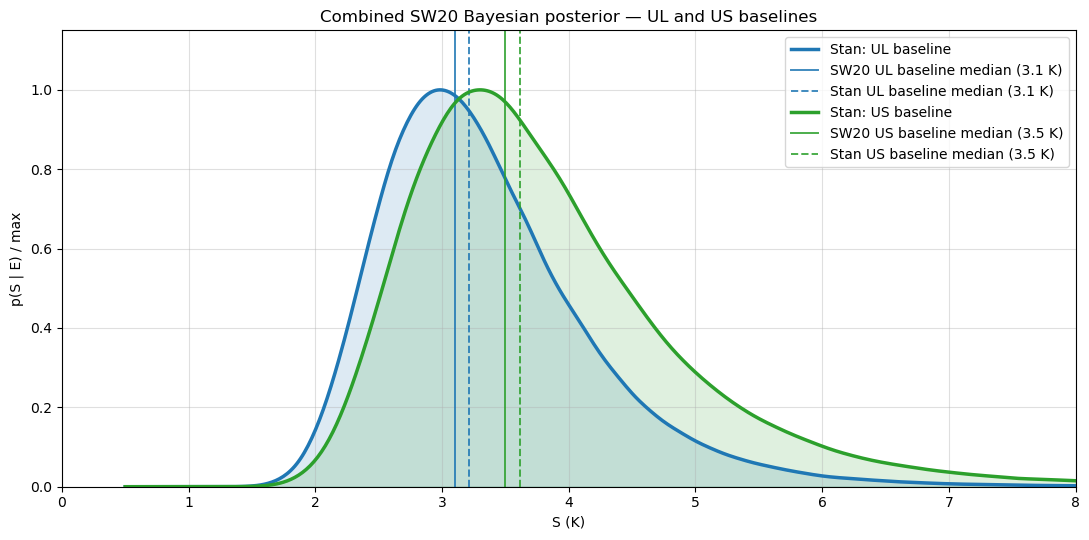

In [15]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coop_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coop_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid); pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

### Revised code and inputs
- All revised equations, but scores Temperature like SW20

In [16]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
coopREV_json_UL = '/tmp/bayecs_cooper_revised_correlated_UL.json'
coopREV_json_US = '/tmp/bayecs_cooper_revised_correlated_US.json'
cmdstanpy.write_stan_json(coopREV_json_UL, coopREV_data_UL)
cmdstanpy.write_stan_json(coopREV_json_US, coopREV_data_US)

common = dict(inits=initREV, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=True,
              show_console=False, refresh=500)

coopREV_fit_UL = coopREV_model.sample(data=coopREV_json_UL, **common)
coopREV_fit_US = coopREV_model.sample(data=coopREV_json_US, **common)

coopREV_S_UL = coopREV_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coopREV_S_US = coopREV_fit_US.draws_xr(vars=['S']).S.values.ravel()

17:08:06 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:10:36 - cmdstanpy - INFO - CmdStan done processing.
17:10:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_revised-correlated.stan', line 187, column 4 to column 46)
Exception: normal_lpdf: Random variable is nan, but must be not nan! (in 'Cooper_revised-correlated.stan', line 191, column 4 to column 50)
Consider re-running with show_console=True if the above output is unclear!


17:10:44 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 8 divergent transitions (0.0%)
	Chain 2 had 9 divergent transitions (0.0%)
	Chain 3 had 5 divergent transitions (0.0%)
	Chain 4 had 10 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [22]:
print(coopREV_fit_UL.diagnose())
print(coopREV_fit_US.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
207 of 500000 (0.04%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
336 of 500000 (0.07%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this d

In [24]:
coopREV_fit_UL.summary().loc[["S", "F_2xCO2", "zeta", "dlambda_LGM", "dlambda_plio"]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.213270e+00,2.231600e-03,0.978748,0.726757,2.122340,3.015960e+00,4.920840,309910.0,245986.0,1243.54,1.00000
F_2xCO2,3.936340e+00,3.519710e-04,0.288902,0.288410,3.460760,3.936270e+00,4.411940,673669.0,333080.0,2703.15,1.00000
zeta,2.818470e-07,1.406160e-07,0.000100,0.000100,-0.000164,2.138440e-07,0.000164,503514.0,335829.0,2020.39,1.00001
dlambda_LGM,-1.042530e-01,6.310890e-04,0.365574,0.365066,-0.701568,-1.062070e-01,0.501343,336181.0,337967.0,1348.95,1.00001
dlambda_plio,-2.079990e-01,7.189430e-04,0.399514,0.398876,-0.857393,-2.129920e-01,0.455837,309592.0,326957.0,1242.26,1.00002


In [76]:
coopREV_fit_UL.summary().loc[["S", "F_2xCO2", "zeta", "dlambda_LGM", "dlambda_plio"]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.290840e+00,2.147890e-03,0.950949,0.721330,2.208090,3.105320e+00,4.962510,292857.0,243150.0,1188.28,1.000010
F_2xCO2,3.937110e+00,3.671120e-04,0.288936,0.289438,3.463670,3.936810e+00,4.411900,619227.0,330018.0,2512.55,1.000000
zeta,-1.395770e-07,1.412610e-07,0.000100,0.000100,-0.000164,-7.740970e-08,0.000164,500168.0,340285.0,2029.46,1.000020
dlambda_LGM,-1.414270e-01,6.327640e-04,0.348912,0.348141,-0.710873,-1.438330e-01,0.436441,304618.0,324947.0,1236.00,0.999998
dlambda_plio,-2.017730e-01,6.939620e-04,0.371408,0.370133,-0.805249,-2.064040e-01,0.415949,287654.0,312269.0,1167.17,1.000000


In [34]:
coopREV_fit_US.summary().loc[["S", "F_2xCO2", "zeta", "dlambda_LGM", "dlambda_plio"]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.936420e+00,4.518060e-03,1.613650,0.984181,2.398840,3.549030e+00,6.686700,239788.0,170180.0,955.748,1.00002
F_2xCO2,3.953800e+00,3.727640e-04,0.288061,0.288324,3.479480,3.953470e+00,4.426820,597037.0,339179.0,2379.680,1.00001
zeta,-2.758880e-07,1.403930e-07,0.000100,0.000100,-0.000165,-3.739580e-07,0.000164,507176.0,325327.0,2021.510,1.00002
dlambda_LGM,-2.233080e-02,7.010490e-04,0.356950,0.356893,-0.603909,-2.511260e-02,0.571258,260101.0,284100.0,1036.710,1.00002
dlambda_plio,-6.525040e-02,7.656010e-04,0.382734,0.382358,-0.686102,-6.936240e-02,0.572030,251369.0,272323.0,1001.910,1.00003


In [34]:
## T left version
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.27 +/- 1.06
  divergences   : 92

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.13 2.45  3.05 3.99  5.09   3.27

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 4.10 +/- 1.97
  divergences   : 1145

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.34 2.75  3.58 5.14  7.59   4.10



In [19]:
## after process change
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.28 +/- 0.94
  divergences   : 68

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.50  3.09 3.98  4.97   3.28

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.93 +/- 1.59
  divergences   : 110

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.38 2.78  3.56 4.87  6.61   3.93



In [24]:
## after process change, but lower corr
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.25 +/- 0.90
  divergences   : 246

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.49  3.07 3.94  4.88   3.25

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.45
  divergences   : 442

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.37 2.75  3.51 4.75  6.32   3.84



In [18]:
## before process change
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.00 +/- 0.76
  divergences   : 124

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.06 2.35  2.87 3.61  4.39   3.00

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.44 +/- 1.14
  divergences   : 124

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.22 2.56  3.20 4.20  5.38   3.44



In [25]:
## reduce inflation of paleo pattern effect
line('UL baseline', coopREV_S_UL, coopREV_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_S_US, coopREV_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.10 +/- 0.74
  divergences   : 28

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.15 2.44  2.97 3.71  4.46   3.10

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.48 +/- 1.00
  divergences   : 108

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.31 2.66  3.29 4.23  5.25   3.48



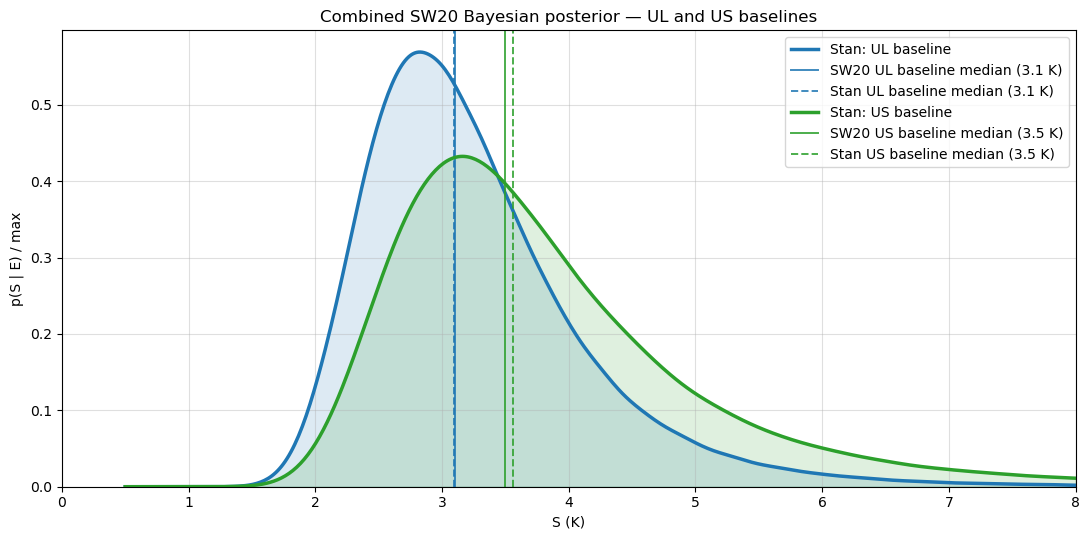

In [20]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

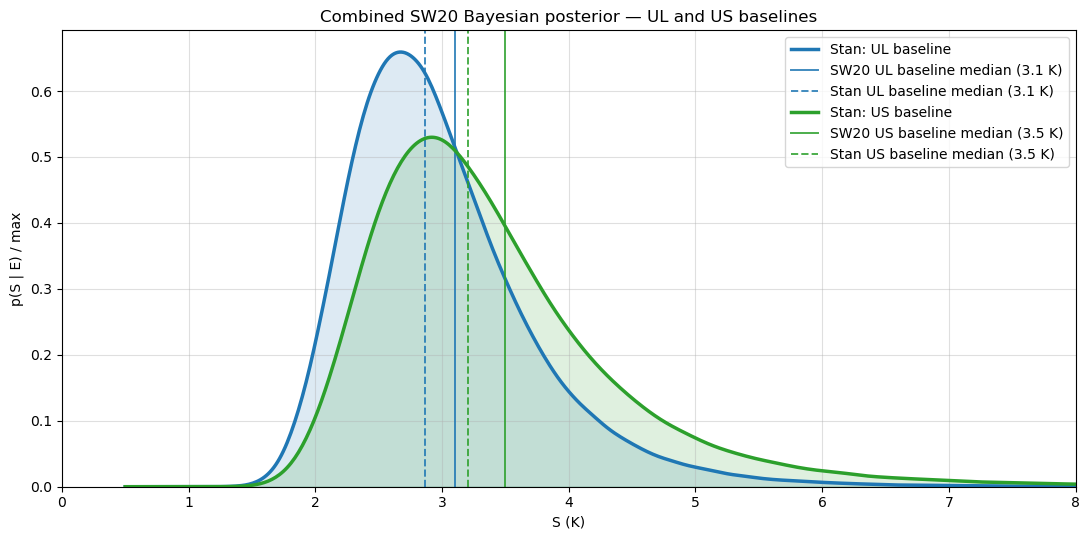

In [20]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

## Score N residual version

In [17]:
# WRite the data to json
# we'll write to versions, one with uniform lambda flag, one with uniform S flag/ 
coopREV_Nresid_json_UL = '/tmp/bayecs_cooper_rev_corr_Nresid_UL.json'
coopREV_Nresid_json_US = '/tmp/bayecs_cooper_rev_corr_Nresid_US.json'
cmdstanpy.write_stan_json(coopREV_Nresid_json_UL, coopREV_data_UL)
cmdstanpy.write_stan_json(coopREV_Nresid_json_US, coopREV_data_US)

common = dict(inits=initREV, chains=N_CHAINS,
              iter_warmup=N_WARMUP, iter_sampling=N_SAMPLES,
              adapt_delta=0.95, show_progress=True,
              show_console=False, refresh=500)

coopREV_Nresid_fit_UL = coopREV_model_Nresid.sample(data=coopREV_Nresid_json_UL, **common)
coopREV_Nresid_fit_US = coopREV_model_Nresid.sample(data=coopREV_Nresid_json_US, **common)

coopREV_Nresid_S_UL = coopREV_Nresid_fit_UL.draws_xr(vars=['S']).S.values.ravel()
coopREV_Nresid_S_US = coopREV_Nresid_fit_US.draws_xr(vars=['S']).S.values.ravel()

17:10:47 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:21:42 - cmdstanpy - INFO - CmdStan done processing.
17:21:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_rev_corr_Nresid.stan', line 195, column 4 to column 46)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_rev_corr_Nresid.stan', line 195, column 4 to column 46)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_rev_corr_Nresid.stan', line 195, column 4 to column 46)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'Cooper_rev_corr_Nresid.stan', line 202, column 4 to column 50)
Consider re-running with show_console=True if the above output is unclear!


In [69]:
print(coopREV_Nresid_fit_UL.diagnose())
print(coopREV_Nresid_fit_US.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
1 of 500000 (0.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

In [18]:
sw20_fit_UL.summary().loc[["S", "dlambda", 
                                     "T_LGM", "T_plio",]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.264740,0.001831,0.821458,0.700551,2.220820,3.125200,4.776360,293098.0,203929.0,3348.58,1.00001
dlambda,0.431287,0.000446,0.270977,0.270513,-0.013573,0.430357,0.878453,370076.0,270151.0,4228.04,1.00002
T_LGM,-5.150030,0.001228,0.837068,0.834094,-6.553190,-5.133540,-3.800920,458698.0,314767.0,5240.53,1.00000
T_plio,2.788080,0.000894,0.753643,0.755065,1.621740,2.745710,4.094690,689365.0,368910.0,7875.85,1.00000


In [85]:
coopREV_Nresid_fit_UL.summary().loc[["S","l", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG']]
                                     # 'CO2_plio','N_LGM','N_plio','N_hist']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.577640,0.002065,0.935755,0.744028,2.465890,3.402970,5.249350,285341.0,250397.0,278.848,1.000010
l,-1.149620,0.000439,0.242935,0.242845,-1.550490,-1.148620,-0.751550,305467.0,257709.0,298.516,1.000020
dlambda,0.631186,0.000418,0.280164,0.279945,0.172418,0.630079,1.095010,449166.0,376374.0,438.945,1.000000
dlambda_LGM,-0.223575,0.000482,0.268023,0.268279,-0.663300,-0.223479,0.217519,309625.0,335571.0,302.579,1.000000
dlambda_plio,-0.247005,0.000543,0.295832,0.295731,-0.731830,-0.248023,0.241225,297169.0,334998.0,290.407,1.000000
T_LGM,-6.155040,0.001264,0.940192,0.940581,-7.711840,-6.148460,-4.620360,553360.0,367663.0,540.768,1.000010
T_plio,4.084890,0.000742,0.574346,0.575308,3.145190,4.081410,5.037140,598648.0,372814.0,585.025,1.000020
F_other_LGM,-3.420980,0.002451,1.551020,1.553770,-6.028630,-3.388100,-0.922967,401255.0,358106.0,392.124,0.999999
F_plio_nonGHG,1.648710,0.001266,0.874981,0.872327,0.215754,1.644420,3.096550,477485.0,369761.0,466.620,1.000010


In [64]:
coopREV_fit_UL.summary().loc[["S","l", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG']]
                                     # 'CO2_plio','N_LGM','N_plio','N_hist']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.618130,0.002478,1.048480,0.798178,2.421330,3.411120,5.480240,260978.0,227460.0,957.824,1.000000
l,-1.154280,0.000499,0.262079,0.262182,-1.586110,-1.153110,-0.724845,274430.0,231626.0,1007.190,1.000010
dlambda,0.670694,0.000431,0.280911,0.280650,0.210309,0.669581,1.134410,425351.0,377384.0,1561.090,1.000000
dlambda_LGM,-0.056924,0.000657,0.337108,0.336852,-0.606499,-0.059956,0.501876,263438.0,314244.0,966.851,1.000010
dlambda_plio,-0.104582,0.000712,0.357167,0.354924,-0.683111,-0.109208,0.491516,252983.0,295404.0,928.479,1.000010
T_LGM,-5.983490,0.001291,0.937521,0.937156,-7.542360,-5.973300,-4.457510,524226.0,377498.0,1923.980,1.000000
T_plio,3.970060,0.000821,0.582674,0.583736,3.019260,3.967060,4.937070,500775.0,362926.0,1837.910,0.999996
F_other_LGM,-4.238280,0.002507,1.635660,1.640090,-6.985700,-4.208570,-1.602850,426334.0,369126.0,1564.700,1.000030
F_plio_nonGHG,1.953840,0.001308,0.889312,0.889535,0.497442,1.947830,3.426840,462825.0,372692.0,1698.630,0.999997


In [63]:
coopREV_Nresid_fit_US.summary().loc[["S","l", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG']]
                                     # 'CO2_plio','N_LGM','N_plio','N_hist']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,4.740570,0.005408,2.136720,1.267660,2.742650,4.176970,8.700890,269874.0,170972.0,164.463,1.00002
l,-0.939376,0.000539,0.286679,0.288787,-1.408380,-0.942233,-0.453070,276195.0,175029.0,168.316,1.00002
dlambda,0.704740,0.000428,0.284076,0.284324,0.238794,0.704321,1.173820,440949.0,357563.0,268.718,1.00001
dlambda_LGM,0.003330,0.000619,0.347663,0.348317,-0.566009,0.001220,0.578454,315312.0,321239.0,192.154,1.00000
dlambda_plio,-0.025878,0.000680,0.369871,0.371239,-0.628612,-0.028703,0.587028,296787.0,308335.0,180.864,1.00001
T_LGM,-6.129320,0.001274,0.948194,0.950400,-7.699230,-6.124300,-4.581070,553591.0,362523.0,337.363,1.00002
T_plio,4.071300,0.000772,0.583566,0.583450,3.117520,4.067420,5.036870,571983.0,365644.0,348.571,1.00001
F_other_LGM,-3.468170,0.002525,1.699050,1.698480,-6.290530,-3.445430,-0.712843,453482.0,349593.0,276.356,1.00001
F_plio_nonGHG,1.656080,0.001284,0.915300,0.913700,0.155304,1.654180,3.167650,507873.0,360896.0,309.502,1.00000


In [65]:
coopREV_fit_US.summary().loc[["S","l", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG']]
                                     # 'CO2_plio','N_LGM','N_plio','N_hist']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,4.358250,0.004877,1.803780,1.102350,2.636100,3.914840,7.507350,257822.0,176962.0,1052.03,1.00001
l,-1.006530,0.000548,0.284218,0.284624,-1.470080,-1.009430,-0.528811,265324.0,178475.0,1082.64,1.00001
dlambda,0.723791,0.000431,0.284146,0.283484,0.257750,0.722732,1.192540,435030.0,355679.0,1775.11,1.00000
dlambda_LGM,0.056089,0.000663,0.344071,0.344617,-0.504105,0.052700,0.628238,270547.0,293962.0,1103.95,1.00001
dlambda_plio,0.024267,0.000717,0.367073,0.366487,-0.571078,0.018888,0.637639,263628.0,284776.0,1075.72,1.00001
T_LGM,-6.021320,0.001289,0.940599,0.941545,-7.583560,-6.013030,-4.485860,530379.0,394533.0,2164.18,1.00000
T_plio,3.986830,0.000821,0.582858,0.583444,3.036860,3.982710,4.954090,501855.0,373476.0,2047.79,1.00001
F_other_LGM,-4.064970,0.002402,1.634170,1.640810,-6.814020,-4.030000,-1.432930,462379.0,367137.0,1886.71,1.00001
F_plio_nonGHG,1.910180,0.001249,0.892984,0.895460,0.449194,1.904890,3.387810,511480.0,365648.0,2087.06,1.00000


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.476030,0.002682,1.079240,0.794600,2.281250,3.254640,5.379610,225205.0,211128.0,177.467,1.000000
l,-1.205630,0.000589,0.287019,0.287116,-1.681040,-1.203940,-0.734444,235755.0,215534.0,185.781,1.000000
dlambda,0.614083,0.000468,0.285635,0.285933,0.146332,0.613125,1.085400,372381.0,367311.0,293.445,1.000010
dlambda_LGM,-0.196005,0.000708,0.350594,0.350059,-0.769456,-0.197297,0.383179,245278.0,305473.0,193.284,1.000000
dlambda_plio,-0.254053,0.000771,0.371225,0.370341,-0.858915,-0.256458,0.361378,231950.0,286237.0,182.782,1.000000
T_LGM,-6.064660,0.001355,0.946029,0.945264,-7.633720,-6.055600,-4.519840,487579.0,378419.0,384.223,1.000010
T_plio,4.044310,0.000819,0.583598,0.583982,3.090320,4.040810,5.011860,507492.0,382255.0,399.916,1.000000
F_other_LGM,-3.809330,0.002802,1.696510,1.697210,-6.635400,-3.784970,-1.057830,366830.0,357478.0,289.070,1.000010
F_plio_nonGHG,1.745690,0.001388,0.913651,0.914255,0.247691,1.741270,3.254190,433229.0,379346.0,341.395,1.000020
CO2_plio,366.871000,0.040888,28.852200,28.885100,319.588000,366.742000,414.377000,496934.0,344735.0,391.596,0.999998


In [57]:
coopREV_Nresid_fit_UL.summary().loc[["S", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG','fCH4']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.424380,0.012554,1.101640,0.804195,2.211010,3.189330,5.353310,10992.2,9313.33,154.483,1.000150
dlambda,0.604954,0.002095,0.286927,0.288907,0.137621,0.604612,1.076130,18818.9,14549.90,264.478,1.000110
dlambda_LGM,-0.152534,0.003114,0.364712,0.358922,-0.749439,-0.157728,0.442803,13772.1,12526.40,193.550,1.000280
dlambda_plio,-0.275676,0.003476,0.399817,0.400017,-0.928674,-0.277778,0.388081,13262.0,13412.70,186.382,0.999982
T_LGM,-6.097380,0.005934,0.940697,0.937798,-7.671250,-6.089790,-4.576340,25230.0,14320.10,354.578,1.000350
T_plio,4.039650,0.003462,0.587155,0.591717,3.084150,4.029320,5.019990,28804.6,14968.00,404.815,1.000200
F_other_LGM,-4.246580,0.012786,1.789050,1.779760,-7.252820,-4.226180,-1.334750,19603.5,14358.20,275.504,1.000380
F_plio_nonGHG,1.750050,0.008170,1.114280,1.109230,-0.077867,1.739560,3.576900,18615.6,13672.30,261.621,1.000430
fCH4,0.429929,0.000432,0.078456,0.077580,0.300833,0.430411,0.560100,33015.3,14611.20,463.992,1.000130


In [76]:
coopREV_Nresid_fit_UL.summary().loc[["S","l", "dlambda", "dlambda_LGM", "dlambda_plio", 
                                     "T_LGM", "T_plio",'F_other_LGM','F_plio_nonGHG','fCH4']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.083610,0.008311,0.831653,0.666289,2.095260,2.924970,4.597980,12135.0,10787.9,183.383,1.00049
l,-1.342110,0.002594,0.294548,0.297724,-1.829200,-1.339600,-0.863087,12795.9,11186.4,193.371,1.00038
dlambda,0.568430,0.002070,0.284361,0.283668,0.101664,0.566341,1.039350,18886.1,15132.0,285.405,1.00072
dlambda_LGM,-0.230629,0.003059,0.358766,0.358174,-0.815295,-0.231075,0.361050,13751.3,13737.9,207.809,1.00014
dlambda_plio,-0.359947,0.003394,0.389164,0.387826,-0.991568,-0.361291,0.293504,13166.0,14250.2,198.964,1.00009
T_LGM,-6.073380,0.006241,0.943253,0.954103,-7.657420,-6.053060,-4.568640,22919.0,13862.6,346.349,1.00013
T_plio,4.027120,0.003987,0.593374,0.596776,3.059760,4.020760,4.998850,22189.9,14556.5,335.331,1.00015
F_other_LGM,-4.417820,0.013524,1.737600,1.704600,-7.298450,-4.395720,-1.545650,16607.5,13709.6,250.971,1.00014
F_plio_nonGHG,1.832050,0.008148,1.116960,1.121240,-0.002267,1.829260,3.682550,18811.5,15092.4,284.277,1.00013
fCH4,0.430108,0.000484,0.079842,0.080515,0.298424,0.430051,0.560324,27260.7,14459.6,411.962,1.00044


In [67]:
## after switch to have both sides be scoring N, using OLD PROCESS LAMBDA
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 20000
  mean +/- std  : 3.08 +/- 0.83
  divergences   : 0

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.10 2.38  2.92 3.73  4.60   3.08

=== US baseline ===
  n_draws       : 20000
  mean +/- std  : 3.67 +/- 1.39
  divergences   : 0

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.27 2.63  3.34 4.53  6.21   3.67



In [52]:
## after switch to have both sides be scoring N
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 20000
  mean +/- std  : 3.47 +/- 1.15
  divergences   : 2

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.21 2.56  3.23 4.26  5.55   3.47

=== US baseline ===
  n_draws       : 20000
  mean +/- std  : 4.58 +/- 2.39
  divergences   : 0

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.47 2.93  3.89 5.83  9.28   4.58



In [15]:
## before process change
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.25 +/- 0.90
  divergences   : 392

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.17 2.49  3.08 3.94  4.87   3.25

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.84 +/- 1.48
  divergences   : 219

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.36 2.75  3.51 4.75  6.33   3.84



In [41]:
## after process change
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.34 +/- 0.95
  divergences   : 24

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.22 2.55  3.16 4.05  5.03   3.34

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.95 +/- 1.50
  divergences   : 0

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.43 2.83  3.61 4.89  6.53   3.95



In [12]:
## latest changes
line('UL baseline', coopREV_Nresid_S_UL, coopREV_Nresid_fit_UL, SHERWOOD_UL)
line('US baseline', coopREV_Nresid_S_US, coopREV_Nresid_fit_US, SHERWOOD_US)

=== UL baseline ===
  n_draws       : 500000
  mean +/- std  : 3.33 +/- 0.94
  divergences   : 17

  First row: Sherwood Table 10 reference (UL baseline):
  Second row: Stan estimate (UL baseline):
    P5  P17  P50  P83  P95   mean
    2.30 2.60  3.10 3.90  4.70   3.20
    2.22 2.55  3.16 4.05  5.02   3.33

=== US baseline ===
  n_draws       : 500000
  mean +/- std  : 3.95 +/- 1.51
  divergences   : 90

  First row: Sherwood Table 10 reference (US baseline):
  Second row: Stan estimate (US baseline):
    P5  P17  P50  P83  P95   mean
    2.40 2.80  3.50 4.50  5.70   3.70
    2.43 2.83  3.61 4.89  6.52   3.95



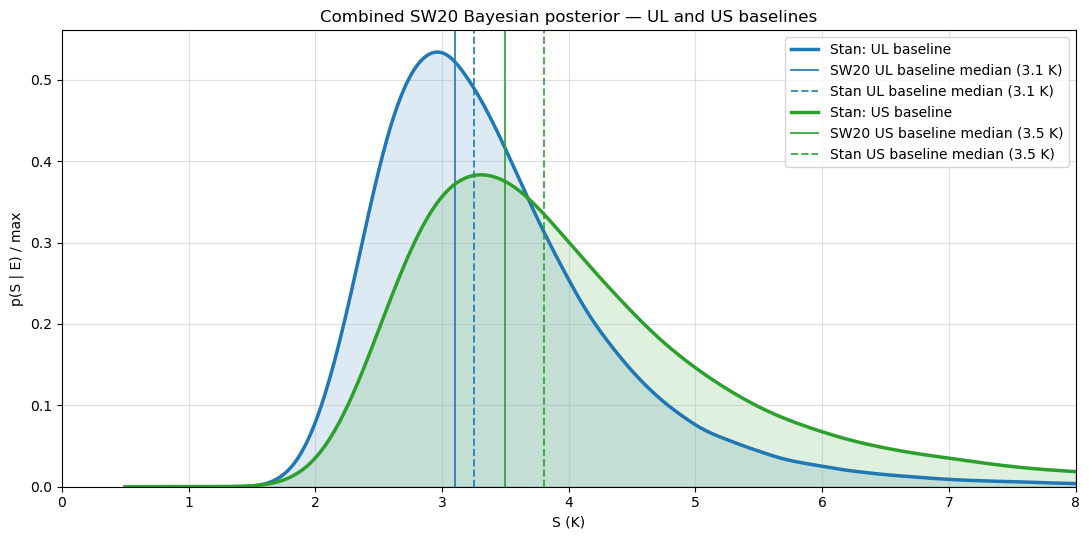

In [78]:
S_grid = np.linspace(0.5, 8, 500)

fig, ax = plt.subplots(figsize=(11, 5.5))

for S, lbl, color, sw in [(coopREV_Nresid_S_UL, 'UL baseline', 'tab:blue',  SHERWOOD_UL),
                            (coopREV_Nresid_S_US, 'US baseline', 'tab:green', SHERWOOD_US)]:
    pdf = gaussian_kde(S, bw_method=0.1)(S_grid)#; pdf /= pdf.max()
    ax.plot(S_grid, pdf, '-', lw=2.5, color=color, label=f'Stan: {lbl}')
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)
    
    # bold line at SW20 median
    ax.axvline(sw[2], color=color, ls='-', lw=1.4, alpha=0.85,
               label=f'SW20 {lbl} median ({sw[2]} K)')

    # bold dashed line at Stan median
    ax.axvline(np.percentile(S,50), color=color, ls='--', lw=1.4, alpha=0.85,
               label=f'Stan {lbl} median ({sw[2]} K)')

# ax.set_xlim(0, 8); ax.set_ylim(0, 1.15)
ax.set_xlim(0, 8); ax.set_ylim(0,)
ax.set_xlabel('S (K)'); ax.set_ylabel('p(S | E) / max')
ax.set_title('Combined SW20 Bayesian posterior — UL and US baselines')
ax.grid(alpha=0.4); ax.legend(loc='upper right')
plt.tight_layout()

# Likelihoods

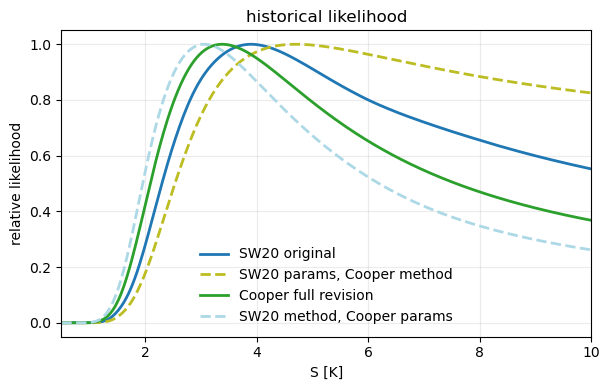

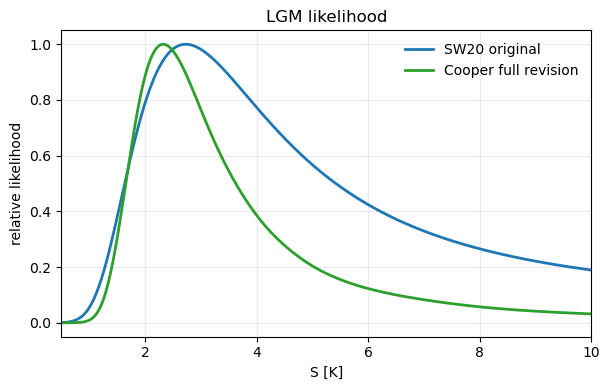

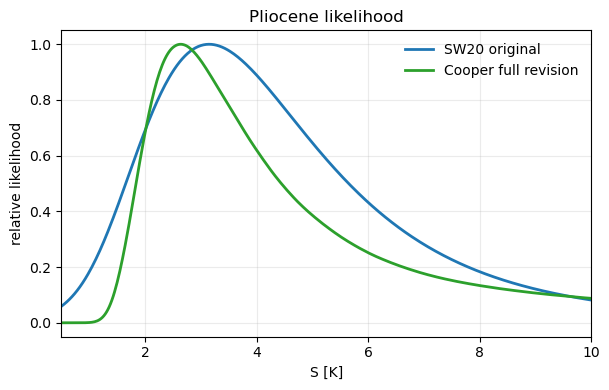

In [18]:
## line-of-evidence likelihood curves for S
from scipy.stats import norm

S_like_grid = np.linspace(0.5, 10.0, 400)
like_mc_n = 50000
like_rng = np.random.default_rng(123)


def _split_normal(mu, sig_low, sig_high, n):
    z = like_rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)


def _draw(d, mu, sig):
    return like_rng.normal(d[mu], d[sig], like_mc_n)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


## sw20 nuisance draws, reused for sw20 original and cooper-sw20 comparisons
f2x_sw = _draw(SW20_BASE, "mu_F2xCO2", "sig_F2xCO2")
zeta_sw = _draw(SW20_BASE, "mu_zeta", "sig_zeta")
f_hist_sw = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    like_mc_n,
)
n_hist_sw = _draw(SW20_BASE, "mu_N_hist", "sig_N_hist")
t_hist_sw = _draw(SW20_BASE, "mu_T_hist", "sig_T_hist")
dl_hist_sw = _draw(SW20_BASE, "mu_dlambda", "sig_dlambda")
t_lgm_sw = _draw(SW20_BASE, "mu_T_LGM", "sig_T_LGM")
alpha_sw = _draw(SW20_BASE, "mu_alpha", "sig_alpha")
co2_plio_sw = _draw(SW20_BASE, "mu_CO2_plio", "sig_CO2_plio")
fch4_sw = _draw(SW20_BASE, "mu_fCH4", "sig_fCH4")
fess_sw = _draw(SW20_BASE, "mu_fESS", "sig_fESS")

## cooper revised nuisance draws
f2x_rev = _draw(coop_REVISED, "mu_F2xCO2", "sig_F2xCO2")
zeta_rev = _draw(coop_REVISED, "mu_zeta", "sig_zeta")
f_hist_rev = _draw(coop_REVISED, "mu_F_hist", "sig_F_hist")
t_hist_rev = _draw(coop_REVISED, "mu_T_hist", "sig_T_hist")
n_hist_rev = _draw(coop_REVISED, "mu_N_hist", "sig_N_hist")
dl_hist_rev = _draw(coop_REVISED, "mu_dlambda", "sig_dlambda")
f_other_lgm_rev = _draw(coop_REVISED, "mu_F_other_LGM", "sig_F_other_LGM")
co2_plio_rev = _draw(coop_REVISED, "mu_CO2_plio", "sig_CO2_plio")
fch4_rev = _draw(coop_REVISED, "mu_fCH4", "sig_fCH4")
f_plio_nonghg_rev = _draw(coop_REVISED, "mu_F_plio_nonGHG", "sig_F_plio_nonGHG")

dl_cov_rev = np.array(
    [
        [coop_REVISED["sig_dlambda_LGM"] ** 2,
         coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"]],
        [coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"],
         coop_REVISED["sig_dlambda_plio"] ** 2],
    ]
)
dl_paleo_rev = like_rng.multivariate_normal(
    [coop_REVISED["mu_dlambda_LGM"], coop_REVISED["mu_dlambda_plio"]],
    dl_cov_rev,
    size=like_mc_n,
)
dl_lgm_rev = dl_paleo_rev[:, 0]
dl_plio_rev = dl_paleo_rev[:, 1]

curves = {"historical": {}, "LGM": {}, "Pliocene": {}}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    ## historical: sw20 original predicts T; cooper versions predict N
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)

    curves["historical"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
    )
    curves["historical"].setdefault("SW20 params, Cooper method", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
    )
    curves["historical"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
    )
    curves["historical"].setdefault("SW20 method, Cooper params", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_hist"], loc=t_hist_rev_pred, scale=coop_REVISED["sig_T_hist"]))
    )

    ## LGM: sw20/cooper-sw20 predict F; cooper revised predicts T
    f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
    t_lgm_rev_pred = (f_other_lgm_rev - 0.57 * f2x_rev) / (dl_lgm_rev - l_rev / (1 + zeta_rev))

    curves["LGM"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    )
    # curves["LGM"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    # )
    curves["LGM"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_LGM"], loc=t_lgm_rev_pred, scale=coop_REVISED["sig_T_LGM"]))
    )

    ## Pliocene: sw20/cooper-sw20 original equation; cooper revised equation
    f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
    t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
    t_plio_rev_pred = (-f_plio_co2_rev * (1 + fch4_rev) - f_plio_nonghg_rev) / (
        l_rev / (1 + zeta_rev) - dl_plio_rev
    )

    curves["Pliocene"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    )
    # curves["Pliocene"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    # )
    curves["Pliocene"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_plio"], loc=t_plio_rev_pred, scale=coop_REVISED["sig_T_plio"]))
    )

styles = {
    "SW20 original": dict(color="tab:blue", ls="-"),
    "SW20 params, Cooper method": dict(color="tab:olive", ls="--"),
    "Cooper full revision": dict(color="tab:green", ls="-"),
    "SW20 method, Cooper params": dict(color="lightblue", ls="--"),
}

for evidence, evidence_curves in curves.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for label, y in evidence_curves.items():
        ax.plot(S_like_grid, _rel(y), lw=2, label=label, **styles[label])
    ax.set(xlabel="S [K]", ylabel="relative likelihood", title=f"{evidence} likelihood")
    ax.set_xlim(S_like_grid.min(), S_like_grid.max())
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()



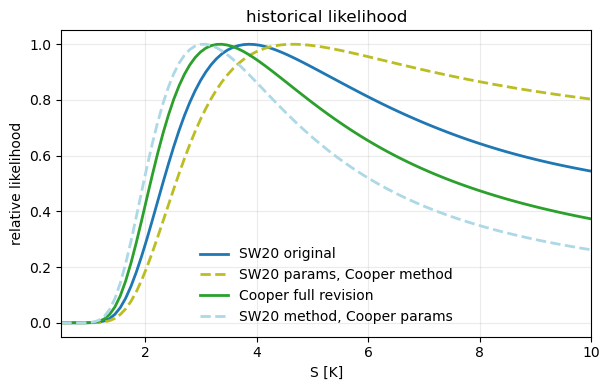

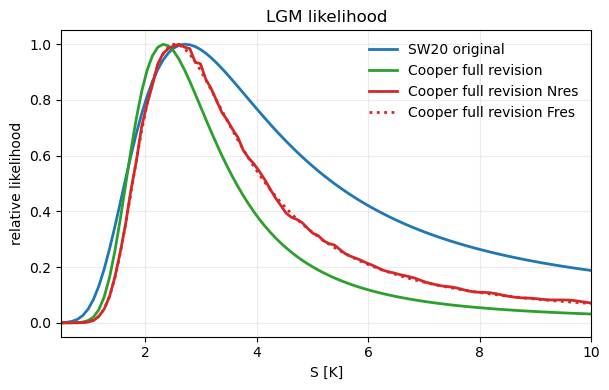

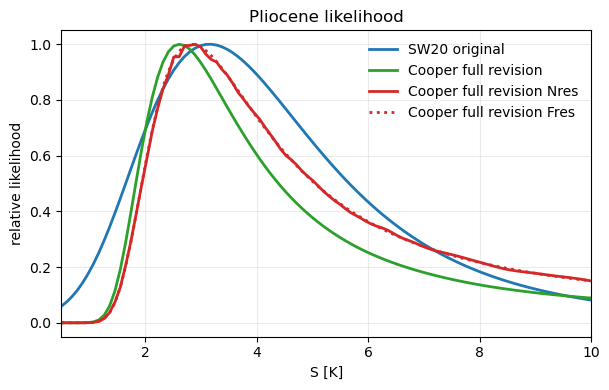

In [19]:
## line-of-evidence likelihood curves for S
from scipy.stats import norm

S_like_grid = np.linspace(0.5, 10.0, 100)
like_mc_n = 500000
like_rng = np.random.default_rng(123)


def _split_normal(mu, sig_low, sig_high, n):
    z = like_rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)


def _draw(d, mu, sig):
    return like_rng.normal(d[mu], d[sig], like_mc_n)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


## sw20 nuisance draws, reused for sw20 original and cooper-sw20 comparisons
f2x_sw = _draw(SW20_BASE, "mu_F2xCO2", "sig_F2xCO2")
zeta_sw = _draw(SW20_BASE, "mu_zeta", "sig_zeta")
f_hist_sw = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    like_mc_n,
)
n_hist_sw = _draw(SW20_BASE, "mu_N_hist", "sig_N_hist")
t_hist_sw = _draw(SW20_BASE, "mu_T_hist", "sig_T_hist")
dl_hist_sw = _draw(SW20_BASE, "mu_dlambda", "sig_dlambda")
t_lgm_sw = _draw(SW20_BASE, "mu_T_LGM", "sig_T_LGM")
alpha_sw = _draw(SW20_BASE, "mu_alpha", "sig_alpha")
co2_plio_sw = _draw(SW20_BASE, "mu_CO2_plio", "sig_CO2_plio")
fch4_sw = _draw(SW20_BASE, "mu_fCH4", "sig_fCH4")
fess_sw = _draw(SW20_BASE, "mu_fESS", "sig_fESS")

## cooper revised nuisance draws
f2x_rev = _draw(coop_REVISED, "mu_F2xCO2", "sig_F2xCO2")
zeta_rev = _draw(coop_REVISED, "mu_zeta", "sig_zeta")
f_hist_rev = _draw(coop_REVISED, "mu_F_hist", "sig_F_hist")
t_hist_rev = _draw(coop_REVISED, "mu_T_hist", "sig_T_hist")
n_hist_rev = _draw(coop_REVISED, "mu_N_hist", "sig_N_hist")
dl_hist_rev = _draw(coop_REVISED, "mu_dlambda", "sig_dlambda")
f_other_lgm_rev = _draw(coop_REVISED, "mu_F_other_LGM", "sig_F_other_LGM")
t_lgm_rev = _draw(coop_REVISED, "mu_T_LGM", "sig_T_LGM")
co2_plio_rev = _draw(coop_REVISED, "mu_CO2_plio", "sig_CO2_plio")
fch4_rev = _draw(coop_REVISED, "mu_fCH4", "sig_fCH4")
f_plio_nonghg_rev = _draw(coop_REVISED, "mu_F_plio_nonGHG", "sig_F_plio_nonGHG")
t_plio_rev = _draw(coop_REVISED, "mu_T_plio", "sig_T_plio")

dl_cov_rev = np.array(
    [
        [coop_REVISED["sig_dlambda_LGM"] ** 2,
         coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"]],
        [coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"],
         coop_REVISED["sig_dlambda_plio"] ** 2],
    ]
)
dl_paleo_rev = like_rng.multivariate_normal(
    [coop_REVISED["mu_dlambda_LGM"], coop_REVISED["mu_dlambda_plio"]],
    dl_cov_rev,
    size=like_mc_n,
)
dl_lgm_rev = dl_paleo_rev[:, 0]
dl_plio_rev = dl_paleo_rev[:, 1]

curves = {"historical": {}, "LGM": {}, "Pliocene": {}}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    ## historical: sw20 original predicts T; cooper versions predict N
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)

    curves["historical"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
    )
    curves["historical"].setdefault("SW20 params, Cooper method", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
    )
    curves["historical"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
    )
    curves["historical"].setdefault("SW20 method, Cooper params", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_hist"], loc=t_hist_rev_pred, scale=coop_REVISED["sig_T_hist"]))
    )

    ## LGM: sw20/cooper-sw20 predict F; cooper revised predicts T
    f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
    t_lgm_rev_pred = (f_other_lgm_rev - 0.57 * f2x_rev) / (dl_lgm_rev - l_rev / (1 + zeta_rev))
    n_lgm_rev_pred = f_other_lgm_rev - 0.57*f2x_rev + t_lgm_rev*(l_rev/(1+zeta_rev) - dl_lgm_rev)
    f_other_lgm_rev_pred = -(- 0.57*f2x_rev + t_lgm_rev*(l_rev/(1+zeta_rev) - dl_lgm_rev))

    curves["LGM"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    )
    # curves["LGM"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    # )
    curves["LGM"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_LGM"], loc=t_lgm_rev_pred, scale=coop_REVISED["sig_T_LGM"]))
    )
    curves["LGM"].setdefault("Cooper full revision Nres", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_LGM"], loc=n_lgm_rev_pred, scale=coop_REVISED["sig_N_LGM"]))
    )
    curves["LGM"].setdefault("Cooper full revision Fres", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred, scale=coop_REVISED["sig_F_other_LGM"]))
    )

    ## Pliocene: sw20/cooper-sw20 original equation; cooper revised equation
    f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
    t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
    t_plio_rev_pred = (-f_plio_co2_rev * (1 + fch4_rev) - f_plio_nonghg_rev) / (
        l_rev / (1 + zeta_rev) - dl_plio_rev
    )
    n_plio_rev_pred = (
        f_plio_co2_rev*(1+fch4_rev) + f_plio_nonghg_rev + 
        t_plio_rev * (l_rev/(1+zeta_rev) - dl_plio_rev)
    )
    f_plio_nonghg_rev_pred = -(
            f_plio_co2_rev * (1 + fch4_rev)
            + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )
        

    curves["Pliocene"].setdefault("SW20 original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    )
    # curves["Pliocene"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    # )
    curves["Pliocene"].setdefault("Cooper full revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_plio"], loc=t_plio_rev_pred, scale=coop_REVISED["sig_T_plio"]))
    )
    curves["Pliocene"].setdefault("Cooper full revision Nres", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_plio"], loc=n_plio_rev_pred, scale=coop_REVISED["sig_N_plio"]))
    )
    curves["Pliocene"].setdefault("Cooper full revision Fres", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred, scale=coop_REVISED["sig_F_plio_nonGHG"]))
    )

styles = {
    "SW20 original": dict(color="tab:blue", ls="-"),
    "SW20 params, Cooper method": dict(color="tab:olive", ls="--"),
    "Cooper full revision": dict(color="tab:green", ls="-"),
    "SW20 method, Cooper params": dict(color="lightblue", ls="--"),
    "Cooper full revision Nres": dict(color="tab:red", ls="-"),
    "Cooper full revision Fres": dict(color="tab:red", ls=":"),
}

for evidence, evidence_curves in curves.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for label, y in evidence_curves.items():
        ax.plot(S_like_grid, _rel(y), lw=2, label=label, **styles[label])
    ax.set(xlabel="S [K]", ylabel="relative likelihood", title=f"{evidence} likelihood")
    ax.set_xlim(S_like_grid.min(), S_like_grid.max())
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()



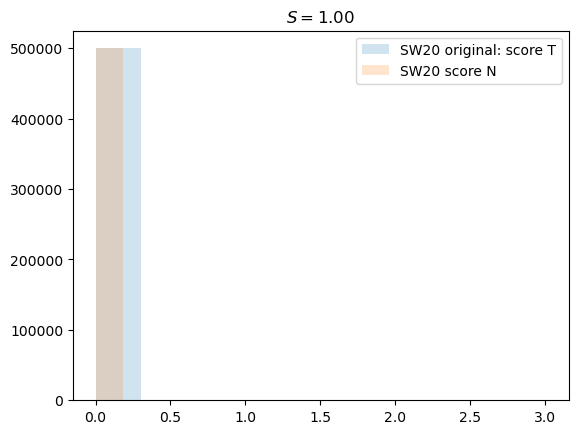

mean T 2.446928818338876e-05 ESS T 67.44551564409844 ESS frac T 0.00013489103128819688
mean N 1.0436065824799168e-05 ESS N 12.803328194645983 ESS frac N 2.5606656389291968e-05


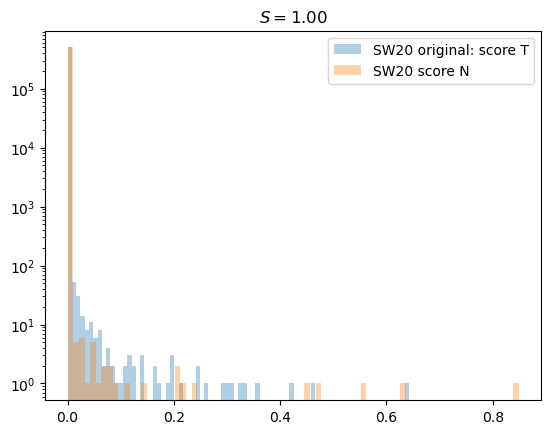

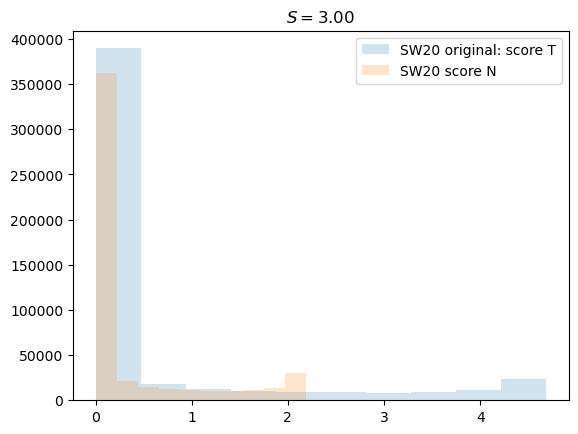

mean T 0.12850200069270154 ESS T 91101.06668008404 ESS frac T 0.18220213336016808
mean N 0.1623137199855842 ESS N 113531.2244193203 ESS frac N 0.22706244883864057


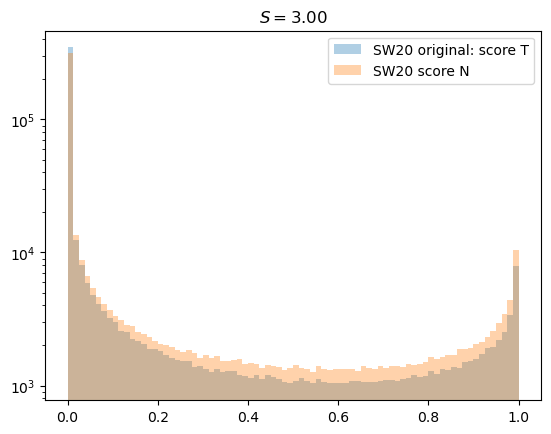

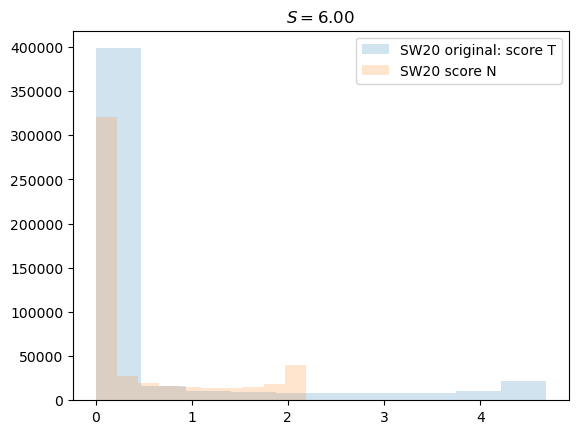

mean T 0.11964174160621646 ESS T 83760.13780828884 ESS frac T 0.16752027561657767
mean N 0.21167340565774384 ESS N 147866.5076842178 ESS frac N 0.2957330153684356


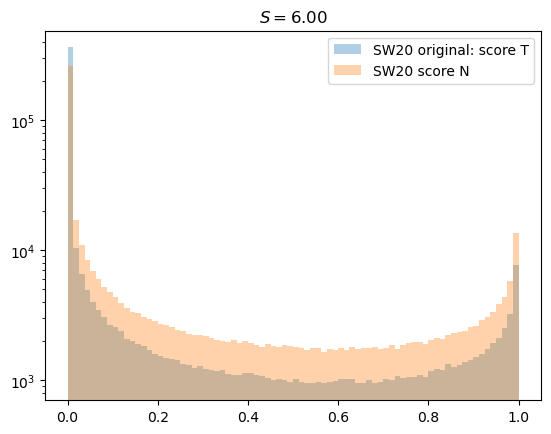

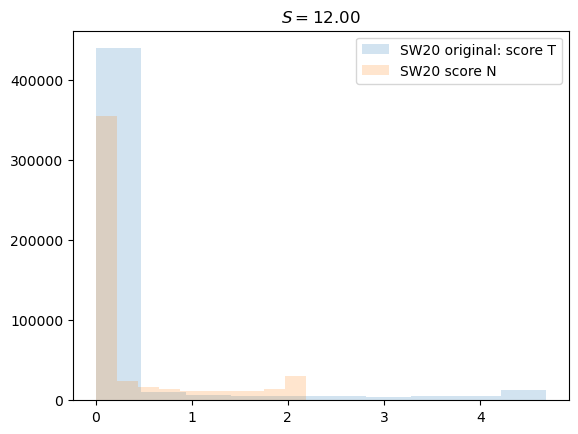

mean T 0.07122270952930691 ESS T 50169.698521510996 ESS frac T 0.10033939704302199
mean N 0.16876274622462437 ESS N 120066.2344913416 ESS frac N 0.2401324689826832


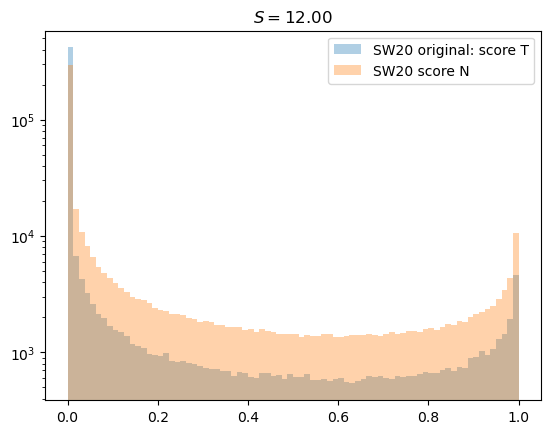

In [20]:
curves = {"historical": {}, "LGM": {}, "Pliocene": {}}

for S in [1.,3.,6.,12.]:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S
    
    ## historical: sw20 original predicts T; cooper versions predict N
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)
    
    plt.hist(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]),
                 label = "SW20 original: score T",
                 alpha=0.2)
    
    plt.hist(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]),
                 label = "SW20 score N",
                 alpha=0.2)
    
    plt.legend()
    plt.title(f'$S = ${S:.2f}')
    plt.show()
    
    w_T = norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"])
    w_T = w_T / norm.pdf(SW20_BASE["mu_T_hist"], loc=SW20_BASE["mu_T_hist"], scale=SW20_BASE["sig_T_hist"])
    w_N = norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"])
    w_N = w_N/norm.pdf(SW20_BASE["mu_N_hist"], loc=SW20_BASE["mu_N_hist"], scale=SW20_BASE["sig_N_hist"])
    
    def weight_ess(w):
        w = np.asarray(w)
        w = w[np.isfinite(w)]
        return w.sum()**2 / np.sum(w**2)
    
    print("mean T", np.nanmean(w_T), "ESS T", weight_ess(w_T), "ESS frac T", weight_ess(w_T)/np.isfinite(w_T).sum())
    print("mean N", np.nanmean(w_N), "ESS N", weight_ess(w_N), "ESS frac N", weight_ess(w_N)/np.isfinite(w_N).sum())
    
    plt.hist(w_T, bins=80, alpha=0.35, label="SW20 original: score T")
    plt.hist(w_N, bins=80, alpha=0.35, label="SW20 score N")
    plt.yscale("log")
    plt.legend()
    plt.title(f'$S = ${S:.2f}')
    plt.show()
    
    def weighted_mean(x, w):
        ok = np.isfinite(x) & np.isfinite(w)
        return np.sum(x[ok] * w[ok]) / np.sum(w[ok])
    
    # for name, w in {"score T": w_T, "score N": w_N}.items():
    #     print(name)
    #     print("F", weighted_mean(f_hist_sw, w))
    #     print("N", weighted_mean(n_hist_sw, w))
    #     print("T", weighted_mean(t_hist_sw, w))
    #     print("dlambda", weighted_mean(dl_hist_sw, w))


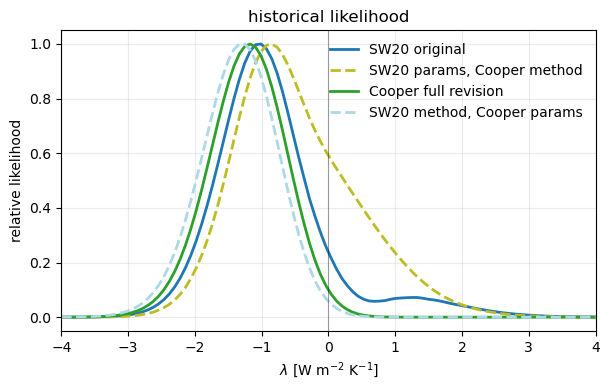

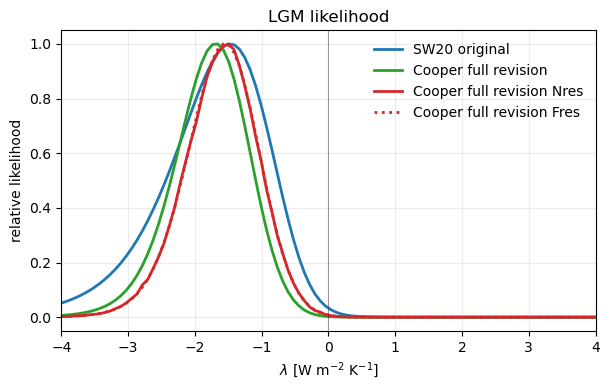

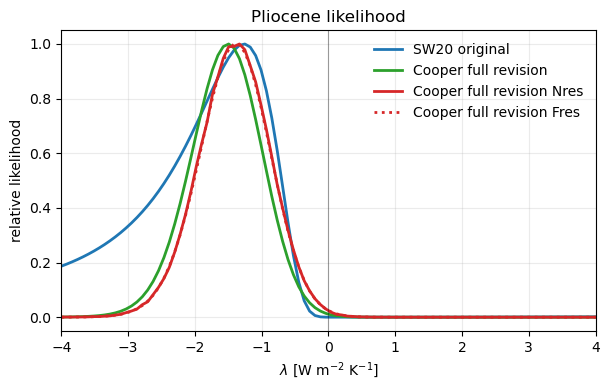

In [13]:
## line-of-evidence likelihood curves for lambda
lambda_like_grid = np.linspace(-4.0, 4.0, 100)
like_mc_n = 500000
like_rng = np.random.default_rng(123)


def _split_normal(mu, sig_low, sig_high, n):
    z = like_rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)


def _draw(d, mu, sig):
    return like_rng.normal(d[mu], d[sig], like_mc_n)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


## sw20 nuisance draws
f2x_sw = _draw(SW20_BASE, "mu_F2xCO2", "sig_F2xCO2")
zeta_sw = _draw(SW20_BASE, "mu_zeta", "sig_zeta")
f_hist_sw = _split_normal(SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"], like_mc_n)
n_hist_sw = _draw(SW20_BASE, "mu_N_hist", "sig_N_hist")
t_hist_sw = _draw(SW20_BASE, "mu_T_hist", "sig_T_hist")
dl_hist_sw = _draw(SW20_BASE, "mu_dlambda", "sig_dlambda")
t_lgm_sw = _draw(SW20_BASE, "mu_T_LGM", "sig_T_LGM")
alpha_sw = _draw(SW20_BASE, "mu_alpha", "sig_alpha")
co2_plio_sw = _draw(SW20_BASE, "mu_CO2_plio", "sig_CO2_plio")
fch4_sw = _draw(SW20_BASE, "mu_fCH4", "sig_fCH4")
fess_sw = _draw(SW20_BASE, "mu_fESS", "sig_fESS")

## cooper revised nuisance draws
f2x_rev = _draw(coop_REVISED, "mu_F2xCO2", "sig_F2xCO2")
zeta_rev = _draw(coop_REVISED, "mu_zeta", "sig_zeta")
f_hist_rev = _draw(coop_REVISED, "mu_F_hist", "sig_F_hist")
t_hist_rev = _draw(coop_REVISED, "mu_T_hist", "sig_T_hist")
n_hist_rev = _draw(coop_REVISED, "mu_N_hist", "sig_N_hist")
dl_hist_rev = _draw(coop_REVISED, "mu_dlambda", "sig_dlambda")
f_other_lgm_rev = _draw(coop_REVISED, "mu_F_other_LGM", "sig_F_other_LGM")
t_lgm_rev = _draw(coop_REVISED, "mu_T_LGM", "sig_T_LGM")
co2_plio_rev = _draw(coop_REVISED, "mu_CO2_plio", "sig_CO2_plio")
fch4_rev = _draw(coop_REVISED, "mu_fCH4", "sig_fCH4")
f_plio_nonghg_rev = _draw(coop_REVISED, "mu_F_plio_nonGHG", "sig_F_plio_nonGHG")
t_plio_rev = _draw(coop_REVISED, "mu_T_plio", "sig_T_plio")

dl_cov_rev = np.array(
    [
        [coop_REVISED["sig_dlambda_LGM"] ** 2,
         coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"]],
        [coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"],
         coop_REVISED["sig_dlambda_plio"] ** 2],
    ]
)

dl_paleo_rev = like_rng.multivariate_normal(
    [coop_REVISED["mu_dlambda_LGM"], coop_REVISED["mu_dlambda_plio"]],
    dl_cov_rev,
    size=like_mc_n,
)
dl_lgm_rev = dl_paleo_rev[:, 0]
dl_plio_rev = dl_paleo_rev[:, 1]

curves_lam = {"historical": {}, "LGM": {}, "Pliocene": {}}

for lam in lambda_like_grid:
    l_sw = lam
    l_rev = lam

    with np.errstate(divide="ignore", invalid="ignore"):
        ## historical
        t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
        n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
        t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
        n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)

        curves_lam["historical"].setdefault("SW20 original", []).append(
            np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
        )
        curves_lam["historical"].setdefault("SW20 params, Cooper method", []).append(
            np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
        )
        curves_lam["historical"].setdefault("Cooper full revision", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
        )
        curves_lam["historical"].setdefault("SW20 method, Cooper params", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_T_hist"], loc=t_hist_rev_pred, scale=coop_REVISED["sig_T_hist"]))
        )

        ## LGM
        f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
        t_lgm_rev_pred = (f_other_lgm_rev - 0.57 * f2x_rev) / (dl_lgm_rev - l_rev / (1 + zeta_rev))
        n_lgm_rev_pred = f_other_lgm_rev - 0.57 * f2x_rev + t_lgm_rev * (l_rev / (1 + zeta_rev) - dl_lgm_rev)
        f_other_lgm_rev_pred = 0.57 * f2x_rev - t_lgm_rev * (l_rev / (1 + zeta_rev) - dl_lgm_rev)

        curves_lam["LGM"].setdefault("SW20 original", []).append(
            np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
        )
        curves_lam["LGM"].setdefault("Cooper full revision", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_T_LGM"], loc=t_lgm_rev_pred, scale=coop_REVISED["sig_T_LGM"]))
        )
        curves_lam["LGM"].setdefault("Cooper full revision Nres", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_N_LGM"], loc=n_lgm_rev_pred, scale=coop_REVISED["sig_N_LGM"]))
        )
        curves_lam["LGM"].setdefault("Cooper full revision Fres", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred, scale=coop_REVISED["sig_F_other_LGM"]))
        )

        ## Pliocene
        f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
        t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

        f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
        t_plio_rev_pred = (-f_plio_co2_rev * (1 + fch4_rev) - f_plio_nonghg_rev) / (
            l_rev / (1 + zeta_rev) - dl_plio_rev
        )
        n_plio_rev_pred = (
            f_plio_co2_rev * (1 + fch4_rev) + f_plio_nonghg_rev
            + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
        )
        f_plio_nonghg_rev_pred = -(
            f_plio_co2_rev * (1 + fch4_rev)
            + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
        )
        

        curves_lam["Pliocene"].setdefault("SW20 original", []).append(
            np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
        )
        curves_lam["Pliocene"].setdefault("Cooper full revision", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_T_plio"], loc=t_plio_rev_pred, scale=coop_REVISED["sig_T_plio"]))
        )
        curves_lam["Pliocene"].setdefault("Cooper full revision Nres", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_N_plio"], loc=n_plio_rev_pred, scale=coop_REVISED["sig_N_plio"]))
        )
        curves_lam["Pliocene"].setdefault("Cooper full revision Fres", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred, scale=coop_REVISED["sig_F_plio_nonGHG"]))
        )

styles = {
    "SW20 original": dict(color="tab:blue", ls="-"),
    "SW20 params, Cooper method": dict(color="tab:olive", ls="--"),
    "Cooper full revision": dict(color="tab:green", ls="-"),
    "SW20 method, Cooper params": dict(color="lightblue", ls="--"),
    "Cooper full revision Nres": dict(color="tab:red", ls="-"),
    "Cooper full revision Fres": dict(color="tab:red", ls=":"),
}

for evidence, evidence_curves in curves_lam.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for label, y in evidence_curves.items():
        ax.plot(lambda_like_grid, _rel(y), lw=2, label=label, **styles[label])
    ax.set(
        xlabel="$\\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="relative likelihood",
        title=f"{evidence} likelihood",
    )
    ax.set_xlim(lambda_like_grid.min(), lambda_like_grid.max())
    ax.axvline(0, color="k", lw=0.8, alpha=0.35)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

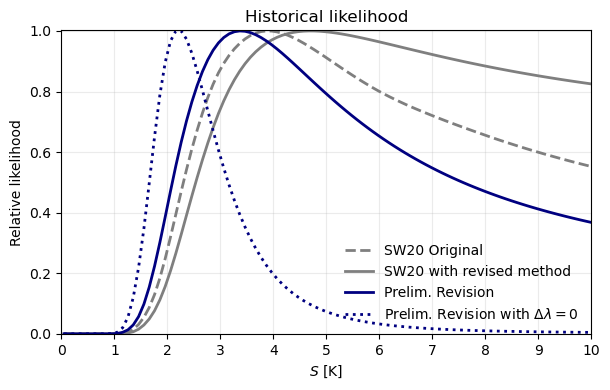

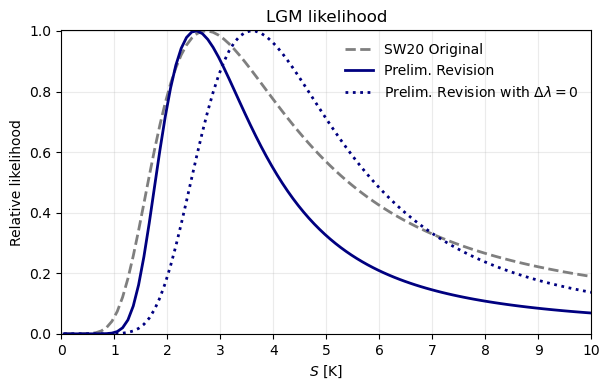

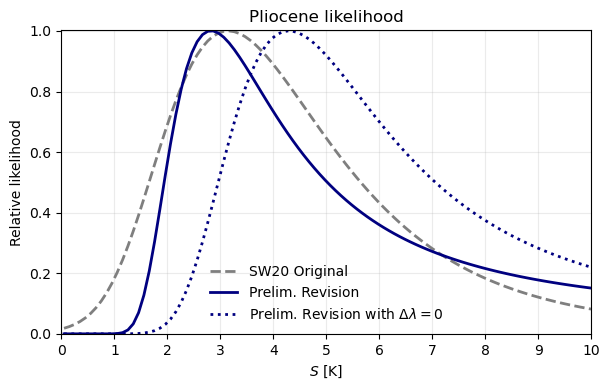

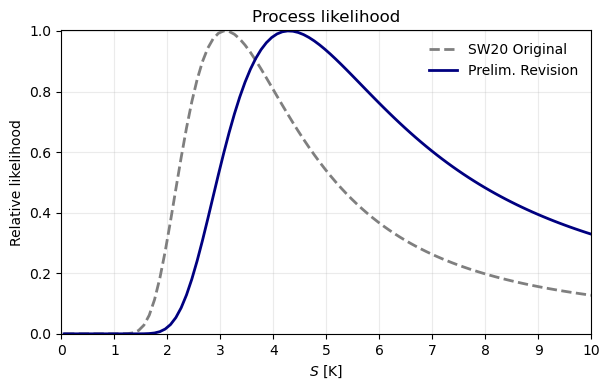

In [14]:
## line-of-evidence likelihood curves for S

S_like_grid = np.linspace(0.05, 10.0, 100)
like_mc_n = 50000
like_rng = np.random.default_rng(123)


def _split_normal(mu, sig_low, sig_high, n):
    z = like_rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)


def _draw(d, mu, sig):
    return like_rng.normal(d[mu], d[sig], like_mc_n)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


## sw20 nuisance draws, reused for sw20 original and cooper-sw20 comparisons
f2x_sw = _draw(SW20_BASE, "mu_F2xCO2", "sig_F2xCO2")
zeta_sw = _draw(SW20_BASE, "mu_zeta", "sig_zeta")
f_hist_sw = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    like_mc_n,
)
n_hist_sw = _draw(SW20_BASE, "mu_N_hist", "sig_N_hist")
t_hist_sw = _draw(SW20_BASE, "mu_T_hist", "sig_T_hist")
dl_hist_sw = _draw(SW20_BASE, "mu_dlambda", "sig_dlambda")
t_lgm_sw = _draw(SW20_BASE, "mu_T_LGM", "sig_T_LGM")
alpha_sw = _draw(SW20_BASE, "mu_alpha", "sig_alpha")
co2_plio_sw = _draw(SW20_BASE, "mu_CO2_plio", "sig_CO2_plio")
fch4_sw = _draw(SW20_BASE, "mu_fCH4", "sig_fCH4")
fess_sw = _draw(SW20_BASE, "mu_fESS", "sig_fESS")

## cooper revised nuisance draws
f2x_rev = _draw(coop_REVISED, "mu_F2xCO2", "sig_F2xCO2")
zeta_rev = _draw(coop_REVISED, "mu_zeta", "sig_zeta")
f_hist_rev = _draw(coop_REVISED, "mu_F_hist", "sig_F_hist")
t_hist_rev = _draw(coop_REVISED, "mu_T_hist", "sig_T_hist")
n_hist_rev = _draw(coop_REVISED, "mu_N_hist", "sig_N_hist")
dl_hist_rev = _draw(coop_REVISED, "mu_dlambda", "sig_dlambda")
f_other_lgm_rev = _draw(coop_REVISED, "mu_F_other_LGM", "sig_F_other_LGM")
t_lgm_rev = _draw(coop_REVISED, "mu_T_LGM", "sig_T_LGM")
co2_plio_rev = _draw(coop_REVISED, "mu_CO2_plio", "sig_CO2_plio")
fch4_rev = _draw(coop_REVISED, "mu_fCH4", "sig_fCH4")
f_plio_nonghg_rev = _draw(coop_REVISED, "mu_F_plio_nonGHG", "sig_F_plio_nonGHG")
t_plio_rev = _draw(coop_REVISED, "mu_T_plio", "sig_T_plio")

dl_cov_rev = np.array(
    [
        [coop_REVISED["sig_dlambda_LGM"] ** 2,
         coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"]],
        [coop_REVISED["rho_dlambda_LGM_plio"] * coop_REVISED["sig_dlambda_LGM"] * coop_REVISED["sig_dlambda_plio"],
         coop_REVISED["sig_dlambda_plio"] ** 2],
    ]
)
dl_paleo_rev = like_rng.multivariate_normal(
    [coop_REVISED["mu_dlambda_LGM"], coop_REVISED["mu_dlambda_plio"]],
    dl_cov_rev,
    size=like_mc_n,
)
dl_lgm_rev = dl_paleo_rev[:, 0]
dl_plio_rev = dl_paleo_rev[:, 1]

curves = {"Historical": {}, "LGM": {}, "Pliocene": {}}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    ## historical: sw20 original predicts T; cooper versions predict N
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    t_hist_rev_pred = -(f_hist_rev - n_hist_rev) / (l_rev - dl_hist_rev)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)
    n_hist_rev_pred_altdl = f_hist_rev + t_hist_rev * (l_rev - 0.)

    curves["Historical"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
    )
    curves["Historical"].setdefault("SW20 with revised method", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
    )
    curves["Historical"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
    )
    curves["Historical"].setdefault("Prelim. Revision with $\Delta \lambda=0$", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred_altdl, scale=coop_REVISED["sig_N_hist"]))
    )
    
    ## LGM: sw20/cooper-sw20 predict F; cooper revised predicts T
    f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
    t_lgm_rev_pred = (f_other_lgm_rev - 0.57 * f2x_rev) / (dl_lgm_rev - l_rev / (1 + zeta_rev))
    n_lgm_rev_pred = f_other_lgm_rev - 0.57*f2x_rev + t_lgm_rev*(l_rev/(1+zeta_rev) - dl_lgm_rev)
    f_other_lgm_rev_pred = -(- 0.57*f2x_rev + t_lgm_rev*(l_rev/(1+zeta_rev) - dl_lgm_rev))
    f_other_lgm_rev_pred_altdl = -(- 0.57*f2x_rev + t_lgm_rev*(l_rev/(1+zeta_rev) - 0.))

    curves["LGM"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    )
    
    # curves["LGM"].setdefault("Cooper full revision", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_T_LGM"], loc=t_lgm_rev_pred, scale=coop_REVISED["sig_T_LGM"]))
    # )
    # curves["LGM"].setdefault("Cooper full revision Nres", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_N_LGM"], loc=n_lgm_rev_pred, scale=coop_REVISED["sig_N_LGM"]))
    # )
    # curves["LGM"].setdefault("Cooper full revision Fres", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred, scale=coop_REVISED["sig_F_other_LGM"]))
    # )
    # curves["LGM"].setdefault("Cooper full revision Nres", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_N_LGM"], loc=n_lgm_rev_pred, scale=coop_REVISED["sig_N_LGM"]))
    # )
    curves["LGM"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred, scale=coop_REVISED["sig_F_other_LGM"]))
    )
    curves["LGM"].setdefault("Prelim. Revision with $\Delta \lambda=0$", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred_altdl, scale=coop_REVISED["sig_F_other_LGM"]))
    )

    ## Pliocene: sw20/cooper-sw20 original equation; cooper revised equation
    f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
    t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
    t_plio_rev_pred = (-f_plio_co2_rev * (1 + fch4_rev) - f_plio_nonghg_rev) / (
        l_rev / (1 + zeta_rev) - dl_plio_rev
    )
    n_plio_rev_pred = (
        f_plio_co2_rev*(1+fch4_rev) + f_plio_nonghg_rev + 
        t_plio_rev * (l_rev/(1+zeta_rev) - dl_plio_rev)
    )
    f_plio_nonghg_rev_pred = -(
            f_plio_co2_rev * (1 + fch4_rev)
            + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )
    f_plio_nonghg_rev_pred_altdl = -(
            f_plio_co2_rev * (1 + fch4_rev)
            + t_plio_rev * (l_rev / (1 + zeta_rev) - 0.)
    )
        

    curves["Pliocene"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    )
    # curves["Pliocene"].setdefault("Cooper, SW20 params", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    # )
    # curves["Pliocene"].setdefault("Prelim. Revision with SW20 method", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_T_plio"], loc=t_plio_rev_pred, scale=coop_REVISED["sig_T_plio"]))
    # )
    # curves["Pliocene"].setdefault("Cooper full revision Nres", []).append(
    #     np.nanmean(norm.pdf(coop_REVISED["mu_N_plio"], loc=n_plio_rev_pred, scale=coop_REVISED["sig_N_plio"]))
    # )
    # curves["Pliocene"].setdefault("Cooper full revision Fres", []).append(
    #         np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred, scale=coop_REVISED["sig_F_plio_nonGHG"]))
    # )
    ## note F score is approx same as N score
    curves["Pliocene"].setdefault("Prelim. Revision", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred, scale=coop_REVISED["sig_F_plio_nonGHG"]))
    )
    curves["Pliocene"].setdefault("Prelim. Revision with $\Delta \lambda=0$", []).append(
            np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred_altdl, scale=coop_REVISED["sig_F_plio_nonGHG"]))
    )

styles = {
    "SW20 Original": dict(color="tab:gray", ls="--"),
    "SW20 original": dict(color="tab:blue", ls="-"),
    "SW20 with revised method": dict(color="tab:gray", ls="-"),
    "Cooper full revision": dict(color="tab:green", ls="-"),
    "SW20 method, Cooper params": dict(color="lightblue", ls="--"),
    "Cooper full revision Nres": dict(color="tab:red", ls="-"),
    "Cooper full revision Fres": dict(color="tab:red", ls=":"),
    "Prelim. Revision": dict(color="navy", ls="-"),
    "Prelim. Revision with SW20 method": dict(color="navy", ls="--"),
    "Prelim. Revision with $\Delta \lambda=0$": dict(color="navy", ls=":"),
}


for evidence, evidence_curves in curves.items():
    # if (evidence == 'historical'):
    fig, ax = plt.subplots(figsize=(6.2, 4.0),dpi=100)
    for label, y in evidence_curves.items():
        ax.plot(S_like_grid, _rel(y), lw=2, label=label, **styles[label])
    ax.set(xlabel="$S$ [K]", ylabel="Relative likelihood", title=f"{evidence} likelihood")
    ax.set_xlim(S_like_grid.min(), S_like_grid.max())
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.ylim(-0.002,1.002)
    plt.xlim(0,S_like_grid.max())
    plt.xticks(np.arange(11))
    plt.tight_layout()
    plt.show()

####
## process likelihood in S space
process_curves = {}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    process_curves.setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(l_sw, loc=SW20_BASE["mu_lambda"], scale=SW20_BASE["sig_lambda"]))
    )

    process_curves.setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(l_rev, loc=coop_REVISED["mu_lambda"], scale=coop_REVISED["sig_lambda"]))
    )

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=100)

for label, y in process_curves.items():
    ax.plot(S_like_grid, _rel(y), lw=2, label=label, **styles[label])

ax.set(
    xlabel="$S$ [K]",
    ylabel="Relative likelihood",
    title="Process likelihood",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()


SW20 Original
uniform lambda prior: {5: 1.91, 17: 2.28, 50: 3.03, 83: 4.4, 95: 6.17}
uniform S prior:      {5: 2.27, 17: 2.82, 50: 4.14, 83: 6.69, 95: 8.72}

Prelim. Revision
uniform lambda prior: {5: 2.54, 17: 3.05, 50: 4.12, 83: 5.99, 95: 7.92}
uniform S prior:      {5: 3.02, 17: 3.77, 50: 5.46, 83: 7.92, 95: 9.3}


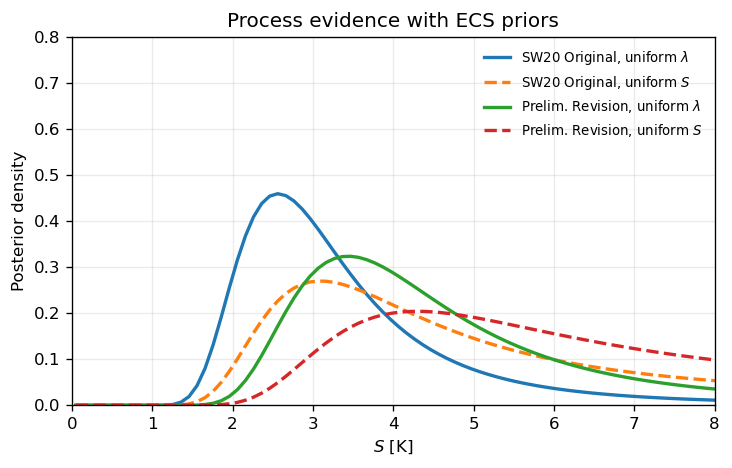

In [18]:
## process evidence with alternative ECS priors
S_grid = np.asarray(S_like_grid)
ok = np.isfinite(S_grid) & (S_grid > 0)

def _pdf_stats(S, pdf):
    pdf = pdf / np.trapz(pdf, S)
    cdf = np.r_[0, np.cumsum(0.5 * (pdf[:-1] + pdf[1:]) * np.diff(S))]
    cdf = cdf / cdf[-1]
    return pdf, {p: np.interp(p / 100, cdf, S) for p in [5, 17, 50, 83, 95]}

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=120)

for label, y in process_curves.items():
    L = np.asarray(y, dtype=float)[ok]
    S = S_grid[ok]

    pdf_uniform_S, pct_uniform_S = _pdf_stats(S, L)

    f2x0 = SW20_BASE["mu_F2xCO2"] if label == "SW20 Original" else coop_REVISED["mu_F2xCO2"]
    pdf_uniform_lambda, pct_uniform_lambda = _pdf_stats(S, L * f2x0 / S**2)

    ax.plot(S, pdf_uniform_lambda, lw=2, label=f"{label}, uniform $\\lambda$")
    ax.plot(S, pdf_uniform_S, lw=2, ls="--", label=f"{label}, uniform $S$")

    print(f"\n{label}")
    print("uniform lambda prior:", {k: round(v, 2) for k, v in pct_uniform_lambda.items()})
    print("uniform S prior:     ", {k: round(v, 2) for k, v in pct_uniform_S.items()})

ax.set_xlabel("$S$ [K]")
ax.set_ylabel("Posterior density")
ax.set_title("Process evidence with ECS priors")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
# ax.set_xlim(0, S_grid[ok].max())
ax.set_xlim(0, 8)
plt.ylim(0,.8)
plt.tight_layout()
plt.show()

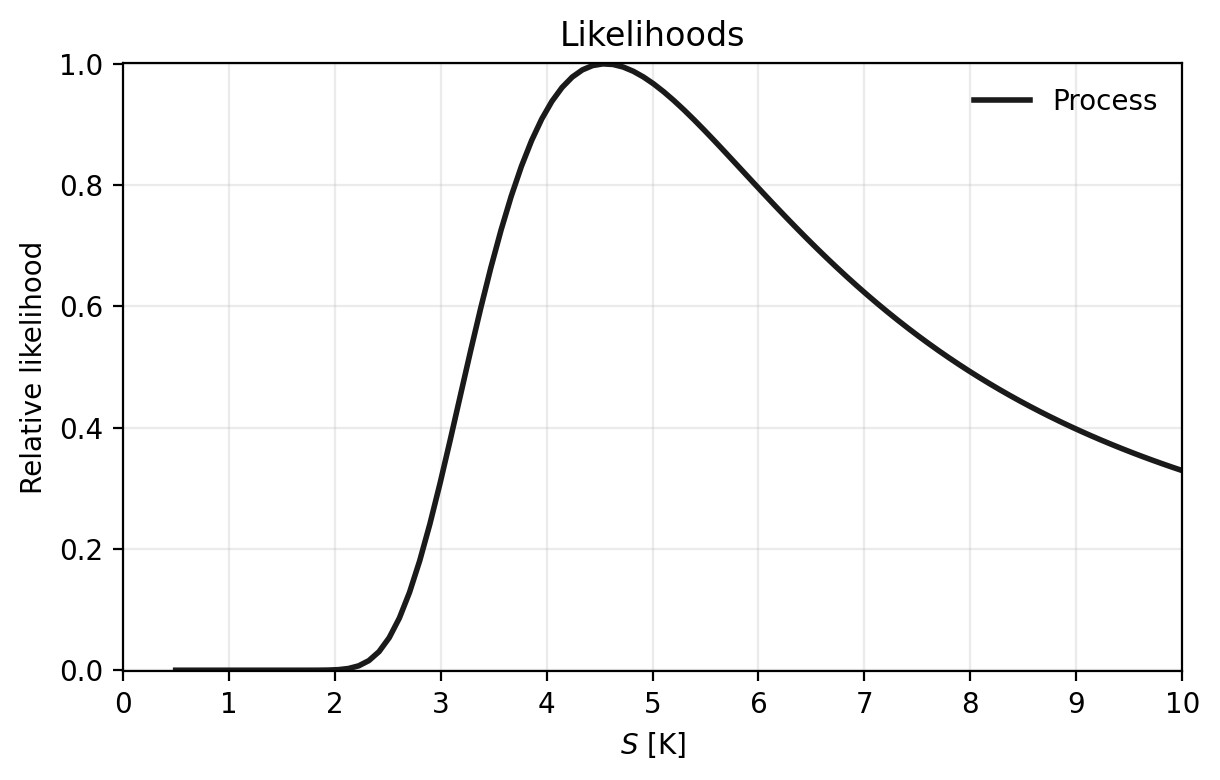

In [86]:
csel = {'Process':'0.2',
        'Historical':'darkorange',
        'LGM':'royalblue',
        'Pliocene':'tab:red'}

fig, ax = plt.subplots(figsize=(6.2, 4.0),dpi=200)
for label, y in process_curves.items():
    if label == 'Prelim. Revision':
        ax.plot(S_like_grid, _rel(y), lw=2, label='Process',c='0.1')

for evidence, evidence_curves in curves.items():
    # if (evidence == 'historical'):
    for label, y in evidence_curves.items():
        if label == 'Prelim. Revision':
            label_alt = evidence
            ax.plot(S_like_grid, _rel(y), lw=2, label=label_alt, c=csel[evidence])
    
ax.set(xlabel="$S$ [K]", ylabel="Relative likelihood", title=f"{evidence} likelihood")
ax.set_xlim(S_like_grid.min(), S_like_grid.max())
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(-0.002,1.002)
plt.xlim(0,S_like_grid.max())
plt.xticks(np.arange(11))
plt.title('Likelihoods')
plt.tight_layout()
plt.show()

In [ ]:
###

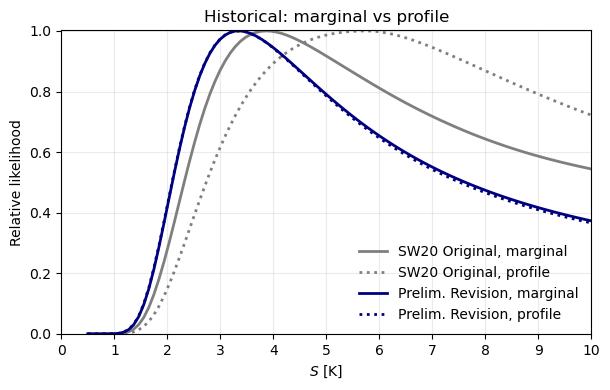

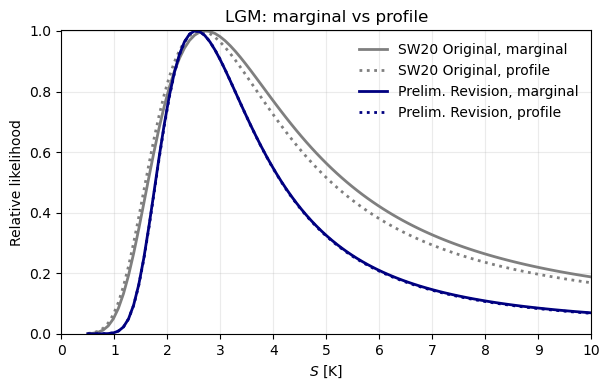

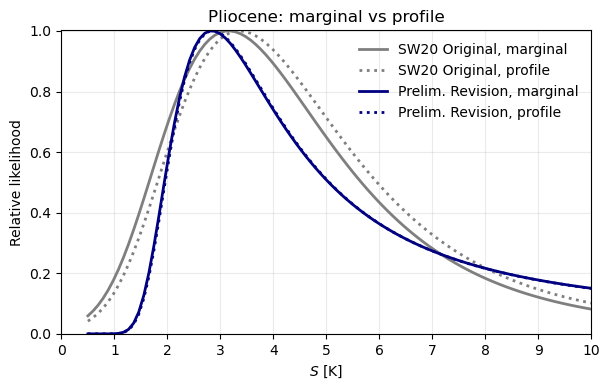

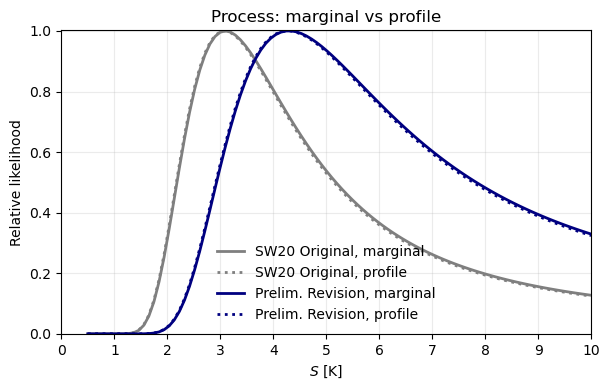

In [25]:
## compare marginal and profile likelihood curves for S
from scipy.optimize import minimize
from scipy.stats import norm

profile_big = 1e30
profile_opts = dict(maxiter=800, ftol=1e-10, xtol=1e-10)


def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)


def _score_nll(obs, pred, sig):
    if not np.isfinite(pred):
        return profile_big
    return 0.5 * ((obs - pred) / sig) ** 2 + np.log(sig)


def _normal_z(z, mu, sig):
    return mu + sig * z, 0.5 * z**2 + np.log(sig)


def _split_z(z, mu, sig_low, sig_high):
    sig = sig_low if z < 0 else sig_high
    return mu + sig * z, 0.5 * z**2 + np.log(sig)


def _profile_curve(obj_builder, z0):
    out = []
    z = np.asarray(z0, dtype=float)
    for S in S_like_grid:
        res = minimize(
            obj_builder(S),
            z,
            method="Powell",
            options=profile_opts,
        )
        if res.success and np.all(np.isfinite(res.x)):
            z = res.x
        out.append(np.exp(-res.fun) if np.isfinite(res.fun) else np.nan)
    return _rel(out)


def _hist_sw_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        f_hist, n = _split_z(z[1], SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"])
        nll += n
        n_hist, n = _normal_z(z[2], SW20_BASE["mu_N_hist"], SW20_BASE["sig_N_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"])
        nll += n
        denom = -f2x / S - dl_hist
        if np.abs(denom) < 1e-8:
            return profile_big
        t_pred = -(f_hist - n_hist) / denom
        return nll + _score_nll(SW20_BASE["mu_T_hist"], t_pred, SW20_BASE["sig_T_hist"])
    return obj


def _hist_rev_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        f_hist, n = _normal_z(z[1], coop_REVISED["mu_F_hist"], coop_REVISED["sig_F_hist"])
        nll += n
        t_hist, n = _normal_z(z[2], coop_REVISED["mu_T_hist"], coop_REVISED["sig_T_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], coop_REVISED["mu_dlambda"], coop_REVISED["sig_dlambda"])
        nll += n
        n_pred = f_hist + t_hist * (-f2x / S - dl_hist)
        return nll + _score_nll(coop_REVISED["mu_N_hist"], n_pred, coop_REVISED["sig_N_hist"])
    return obj


def _lgm_sw_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        zeta, n = _normal_z(z[1], SW20_BASE["mu_zeta"], SW20_BASE["sig_zeta"])
        nll += n
        t_lgm, n = _normal_z(z[2], SW20_BASE["mu_T_LGM"], SW20_BASE["sig_T_LGM"])
        nll += n
        alpha, n = _normal_z(z[3], SW20_BASE["mu_alpha"], SW20_BASE["sig_alpha"])
        nll += n
        if 1 + zeta <= 0:
            return profile_big
        f_pred = 0.57 * f2x - t_lgm * ((-f2x / S) / (1 + zeta) + alpha / 2 * t_lgm)
        return nll + _score_nll(SW20_BASE["mu_F_LGM"], f_pred, SW20_BASE["sig_F_LGM"])
    return obj


def _lgm_rev_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        zeta, n = _normal_z(z[1], coop_REVISED["mu_zeta"], coop_REVISED["sig_zeta"])
        nll += n
        t_lgm, n = _normal_z(z[2], coop_REVISED["mu_T_LGM"], coop_REVISED["sig_T_LGM"])
        nll += n
        dl_lgm, n = _normal_z(z[3], coop_REVISED["mu_dlambda_LGM"], coop_REVISED["sig_dlambda_LGM"])
        nll += n
        if 1 + zeta <= 0:
            return profile_big
        f_pred = -( -0.57 * f2x + t_lgm * ((-f2x / S) / (1 + zeta) - dl_lgm) )
        return nll + _score_nll(coop_REVISED["mu_F_other_LGM"], f_pred, coop_REVISED["sig_F_other_LGM"])
    return obj


def _plio_sw_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        zeta, n = _normal_z(z[1], SW20_BASE["mu_zeta"], SW20_BASE["sig_zeta"])
        nll += n
        co2, n = _normal_z(z[2], SW20_BASE["mu_CO2_plio"], SW20_BASE["sig_CO2_plio"])
        nll += n
        fch4, n = _normal_z(z[3], SW20_BASE["mu_fCH4"], SW20_BASE["sig_fCH4"])
        nll += n
        fess, n = _normal_z(z[4], SW20_BASE["mu_fESS"], SW20_BASE["sig_fESS"])
        nll += n
        if co2 <= 0 or 1 + zeta <= 0 or np.abs(f2x / S) < 1e-8:
            return profile_big
        f_co2 = np.log(co2 / 284) / np.log(2) * f2x
        t_pred = (-f_co2 * (1 + fch4) * (1 + fess)) / ((-f2x / S) / (1 + zeta))
        return nll + _score_nll(SW20_BASE["mu_T_plio"], t_pred, SW20_BASE["sig_T_plio"])
    return obj


def _plio_rev_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        zeta, n = _normal_z(z[1], coop_REVISED["mu_zeta"], coop_REVISED["sig_zeta"])
        nll += n
        co2, n = _normal_z(z[2], coop_REVISED["mu_CO2_plio"], coop_REVISED["sig_CO2_plio"])
        nll += n
        fch4, n = _normal_z(z[3], coop_REVISED["mu_fCH4"], coop_REVISED["sig_fCH4"])
        nll += n
        t_plio, n = _normal_z(z[4], coop_REVISED["mu_T_plio"], coop_REVISED["sig_T_plio"])
        nll += n
        dl_plio, n = _normal_z(z[5], coop_REVISED["mu_dlambda_plio"], coop_REVISED["sig_dlambda_plio"])
        nll += n
        if co2 <= 0 or 1 + zeta <= 0:
            return profile_big
        f_co2 = np.log(co2 / 284) / np.log(2) * f2x
        f_pred = -(f_co2 * (1 + fch4) + t_plio * ((-f2x / S) / (1 + zeta) - dl_plio))
        return nll + _score_nll(coop_REVISED["mu_F_plio_nonGHG"], f_pred, coop_REVISED["sig_F_plio_nonGHG"])
    return obj


def _process_sw_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        return nll + _score_nll(SW20_BASE["mu_lambda"], -f2x / S, SW20_BASE["sig_lambda"])
    return obj


def _process_rev_profile_obj(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        return nll + _score_nll(coop_REVISED["mu_lambda"], -f2x / S, coop_REVISED["sig_lambda"])
    return obj


marginal_curves = {"Historical": {}, "LGM": {}, "Pliocene": {}, "Process": {}}

for S in S_like_grid:
    l_sw = -f2x_sw / S
    l_rev = -f2x_rev / S

    ## historical
    t_hist_sw_pred = -(f_hist_sw - n_hist_sw) / (l_sw - dl_hist_sw)
    n_hist_sw_pred = f_hist_sw + t_hist_sw * (l_sw - dl_hist_sw)
    n_hist_rev_pred = f_hist_rev + t_hist_rev * (l_rev - dl_hist_rev)

    marginal_curves["Historical"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_hist_sw_pred, scale=SW20_BASE["sig_T_hist"]))
    )
    # marginal_curves["Historical"].setdefault("SW20 Original, Cooper method", []).append(
    #     np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_hist_sw_pred, scale=SW20_BASE["sig_N_hist"]))
    # )
    marginal_curves["Historical"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_hist_rev_pred, scale=coop_REVISED["sig_N_hist"]))
    )

    ## lgm
    f_lgm_sw_pred = 0.57 * f2x_sw - t_lgm_sw * (l_sw / (1 + zeta_sw) + alpha_sw / 2 * t_lgm_sw)
    f_other_lgm_rev_pred = -( -0.57 * f2x_rev + t_lgm_rev * (l_rev / (1 + zeta_rev) - dl_lgm_rev) )

    marginal_curves["LGM"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_F_LGM"], loc=f_lgm_sw_pred, scale=SW20_BASE["sig_F_LGM"]))
    )
    marginal_curves["LGM"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_F_other_LGM"], loc=f_other_lgm_rev_pred, scale=coop_REVISED["sig_F_other_LGM"]))
    )

    ## pliocene
    f_plio_co2_sw = np.log(co2_plio_sw / 284) / np.log(2) * f2x_sw
    t_plio_sw_pred = (-f_plio_co2_sw * (1 + fch4_sw) * (1 + fess_sw)) / (l_sw / (1 + zeta_sw))

    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev
    f_plio_nonghg_rev_pred = -(
        f_plio_co2_rev * (1 + fch4_rev)
        + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )

    marginal_curves["Pliocene"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_plio"], loc=t_plio_sw_pred, scale=SW20_BASE["sig_T_plio"]))
    )
    marginal_curves["Pliocene"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(coop_REVISED["mu_F_plio_nonGHG"], loc=f_plio_nonghg_rev_pred, scale=coop_REVISED["sig_F_plio_nonGHG"]))
    )

    ## process
    marginal_curves["Process"].setdefault("SW20 Original", []).append(
        np.nanmean(norm.pdf(l_sw, loc=SW20_BASE["mu_lambda"], scale=SW20_BASE["sig_lambda"]))
    )
    marginal_curves["Process"].setdefault("Prelim. Revision", []).append(
        np.nanmean(norm.pdf(l_rev, loc=coop_REVISED["mu_lambda"], scale=coop_REVISED["sig_lambda"]))
    )


profile_curves = {
    "Historical": {
        "SW20 Original": _profile_curve(_hist_sw_profile_obj, np.zeros(4)),
        "SW20 Original, Cooper method": _profile_curve(_hist_sw_profile_obj, np.zeros(4)),
        "Prelim. Revision": _profile_curve(_hist_rev_profile_obj, np.zeros(4)),
    },
    "LGM": {
        "SW20 Original": _profile_curve(_lgm_sw_profile_obj, np.zeros(4)),
        "Prelim. Revision": _profile_curve(_lgm_rev_profile_obj, np.zeros(4)),
    },
    "Pliocene": {
        "SW20 Original": _profile_curve(_plio_sw_profile_obj, np.zeros(5)),
        "Prelim. Revision": _profile_curve(_plio_rev_profile_obj, np.zeros(6)),
    },
    "Process": {
        "SW20 Original": _profile_curve(_process_sw_profile_obj, np.zeros(1)),
        "Prelim. Revision": _profile_curve(_process_rev_profile_obj, np.zeros(1)),
    },
}

styles = {
    "SW20 Original": dict(color="tab:gray"),
    # "SW20 Original, Cooper method": dict(color="b"),
    "Prelim. Revision": dict(color="navy"),
}

for evidence, evidence_curves in marginal_curves.items():
    fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=100)

    for label, y in evidence_curves.items():
        ax.plot(S_like_grid, _rel(y), lw=2, ls="-", label=f"{label}, marginal", **styles[label])
        ax.plot(S_like_grid, profile_curves[evidence][label], lw=2, ls=":", label=f"{label}, profile", **styles[label])

    ax.set(xlabel="$S$ [K]", ylabel="Relative likelihood", title=f"{evidence}: marginal vs profile")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.ylim(-0.002, 1.002)
    plt.xlim(0, S_like_grid.max())
    plt.xticks(np.arange(11))
    plt.tight_layout()
    plt.show()


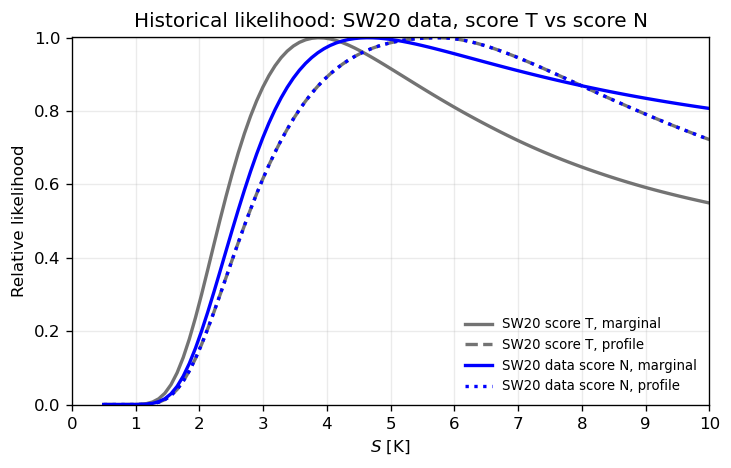

In [28]:
## historical likelihood: SW20 data, compare score-T vs score-N methods
from scipy.optimize import minimize
from scipy.stats import norm

profile_big = 1e30
profile_opts = dict(maxiter=800, ftol=1e-10, xtol=1e-10)

def _rel(y):
    y = np.asarray(y, dtype=float)
    return y / np.nanmax(y)

def _score_nll(obs, pred, sig):
    if not np.isfinite(pred):
        return profile_big
    return 0.5 * ((obs - pred) / sig) ** 2 + np.log(sig)

def _normal_z(z, mu, sig):
    return mu + sig * z, 0.5 * z**2 + np.log(sig)

def _split_z(z, mu, sig_low, sig_high):
    sig = sig_low if z < 0 else sig_high
    return mu + sig * z, 0.5 * z**2 + np.log(sig)

def _split_normal(mu, sig_low, sig_high, n, rng):
    z = rng.normal(size=n)
    return np.where(z < 0, mu + z * sig_low, mu + z * sig_high)

def _profile_curve(obj_builder, z0):
    out = []
    z = np.asarray(z0, dtype=float)
    for S in S_like_grid:
        res = minimize(obj_builder(S), z, method="Powell", options=profile_opts)
        if res.success and np.all(np.isfinite(res.x)):
            z = res.x
        out.append(np.exp(-res.fun) if np.isfinite(res.fun) else np.nan)
    return _rel(out)

## make SW20 nuisance draws
hist_rng = np.random.default_rng(123)
hist_mc_n = 500000

f2x_sw_h = hist_rng.normal(SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"], hist_mc_n)
f_hist_sw_h = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    hist_mc_n,
    hist_rng,
)
n_hist_sw_h = hist_rng.normal(SW20_BASE["mu_N_hist"], SW20_BASE["sig_N_hist"], hist_mc_n)
t_hist_sw_h = hist_rng.normal(SW20_BASE["mu_T_hist"], SW20_BASE["sig_T_hist"], hist_mc_n)
dl_hist_sw_h = hist_rng.normal(SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"], hist_mc_n)

## profile: SW20 original method, score T
def _hist_sw_profile_score_T(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        f_hist, n = _split_z(z[1], SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"])
        nll += n
        n_hist, n = _normal_z(z[2], SW20_BASE["mu_N_hist"], SW20_BASE["sig_N_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"])
        nll += n

        denom = -f2x / S - dl_hist
        if np.abs(denom) < 1e-8:
            return profile_big

        t_pred = -(f_hist - n_hist) / denom
        return nll + _score_nll(SW20_BASE["mu_T_hist"], t_pred, SW20_BASE["sig_T_hist"])
    return obj

## profile: Cooper method with SW20 data, score N
def _hist_sw_profile_score_N(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        f_hist, n = _split_z(z[1], SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"])
        nll += n
        t_hist, n = _normal_z(z[2], SW20_BASE["mu_T_hist"], SW20_BASE["sig_T_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"])
        nll += n

        n_pred = f_hist + t_hist * (-f2x / S - dl_hist)
        return nll + _score_nll(SW20_BASE["mu_N_hist"], n_pred, SW20_BASE["sig_N_hist"])
    return obj

L_T_marg = []
L_N_marg = []

for S in S_like_grid:
    l_sw = -f2x_sw_h / S

    t_pred = -(f_hist_sw_h - n_hist_sw_h) / (l_sw - dl_hist_sw_h)
    L_T_marg.append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_pred, scale=SW20_BASE["sig_T_hist"]))
    )

    n_pred = f_hist_sw_h + t_hist_sw_h * (l_sw - dl_hist_sw_h)
    L_N_marg.append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_pred, scale=SW20_BASE["sig_N_hist"]))
    )

L_T_marg = _rel(L_T_marg)
L_N_marg = _rel(L_N_marg)

L_T_prof = _profile_curve(_hist_sw_profile_score_T, np.zeros(4))
L_N_prof = _profile_curve(_hist_sw_profile_score_N, np.zeros(4))

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=120)

ax.plot(S_like_grid, L_T_marg, color="0.45", lw=2, label="SW20 score T, marginal")
ax.plot(S_like_grid, L_T_prof, color="0.45", lw=2, ls="--", label="SW20 score T, profile")

ax.plot(S_like_grid, L_N_marg, color="b", lw=2, label="SW20 data score N, marginal")
ax.plot(S_like_grid, L_N_prof, color="b", lw=2, ls=":", label="SW20 data score N, profile")

ax.set(
    xlabel="$S$ [K]",
    ylabel="Relative likelihood",
    title="Historical likelihood: SW20 data, score T vs score N",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

"""
There are 2 problems with SW20 likelihood calc. 
1) it doesn't match the profile likelihood because of the
ratio singularity.
2) it doesn't match the profile likelihood because of the
skewed aerosol forcing.
This is why my correction (score N) still doesn't match
the profile likelihood using sw20 data.
However, using the revised data, score N matches the 
profile likelihood.

marginal likelihood and profile likelihood are 
different operations, and they only look similar 
when the nuisance-parameter geometry is close to 
linear/Gaussian.
marginal likelihood = average fit over nuisance space
profile likelihood  = best possible fit over nuisance space.

under SW20’s original asymmetric historical forcing 
assumptions, the historical likelihood is method-sensitive;
under the revised Gaussianized/updated assumptions, 
the marginal and profile versions are more stable.
"""

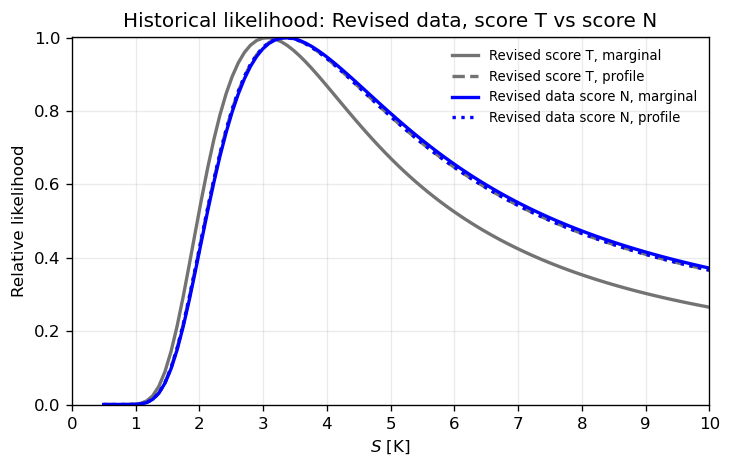

In [38]:
f2x_rev_h = hist_rng.normal(coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"], hist_mc_n)
f_hist_rev_h = hist_rng.normal(
    coop_REVISED["mu_F_hist"],
    coop_REVISED["sig_F_hist"],
    hist_mc_n,
)
n_hist_rev_h = hist_rng.normal(coop_REVISED["mu_N_hist"], coop_REVISED["sig_N_hist"], hist_mc_n)
t_hist_rev_h = hist_rng.normal(coop_REVISED["mu_T_hist"], coop_REVISED["sig_T_hist"], hist_mc_n)
dl_hist_rev_h = hist_rng.normal(coop_REVISED["mu_dlambda"], coop_REVISED["sig_dlambda"], hist_mc_n)

## profile: Revised original method, score T
def _hist_rev_profile_score_T(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        f_hist, n = _normal_z(z[1], coop_REVISED["mu_F_hist"], coop_REVISED["sig_F_hist"])
        nll += n
        n_hist, n = _normal_z(z[2], coop_REVISED["mu_N_hist"], coop_REVISED["sig_N_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], coop_REVISED["mu_dlambda"], coop_REVISED["sig_dlambda"])
        nll += n

        denom = -f2x / S - dl_hist
        if np.abs(denom) < 1e-8:
            return profile_big

        t_pred = -(f_hist - n_hist) / denom
        return nll + _score_nll(coop_REVISED["mu_T_hist"], t_pred, coop_REVISED["sig_T_hist"])
    return obj

## profile: Cooper method with Revised data, score N
def _hist_rev_profile_score_N(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"])
        f_hist, n = _normal_z(z[1], coop_REVISED["mu_F_hist"], coop_REVISED["sig_F_hist"])
        nll += n
        t_hist, n = _normal_z(z[2], coop_REVISED["mu_T_hist"], coop_REVISED["sig_T_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], coop_REVISED["mu_dlambda"], coop_REVISED["sig_dlambda"])
        nll += n

        n_pred = f_hist + t_hist * (-f2x / S - dl_hist)
        return nll + _score_nll(coop_REVISED["mu_N_hist"], n_pred, coop_REVISED["sig_N_hist"])
    return obj

L_T_marg = []
L_N_marg = []

for S in S_like_grid:
    l_rev = -f2x_rev_h / S

    t_pred = -(f_hist_rev_h - n_hist_rev_h) / (l_rev - dl_hist_rev_h)
    L_T_marg.append(
        np.nanmean(norm.pdf(coop_REVISED["mu_T_hist"], loc=t_pred, scale=coop_REVISED["sig_T_hist"]))
    )

    n_pred = f_hist_rev_h + t_hist_rev_h * (l_rev - dl_hist_rev_h)
    L_N_marg.append(
        np.nanmean(norm.pdf(coop_REVISED["mu_N_hist"], loc=n_pred, scale=coop_REVISED["sig_N_hist"]))
    )

L_T_marg = _rel(L_T_marg)
L_N_marg = _rel(L_N_marg)

L_T_prof = _profile_curve(_hist_rev_profile_score_T, np.zeros(4))
L_N_prof = _profile_curve(_hist_rev_profile_score_N, np.zeros(4))

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=120)

ax.plot(S_like_grid, L_T_marg, color="0.45", lw=2, label="Revised score T, marginal")
ax.plot(S_like_grid, L_T_prof, color="0.45", lw=2, ls="--", label="Revised score T, profile")

ax.plot(S_like_grid, L_N_marg, color="b", lw=2, label="Revised data score N, marginal")
ax.plot(S_like_grid, L_N_prof, color="b", lw=2, ls=":", label="Revised data score N, profile")

ax.set(
    xlabel="$S$ [K]",
    ylabel="Relative likelihood",
    title="Historical likelihood: Revised data, score T vs score N",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

In [ ]:
f2x_sw_h = hist_rng.normal(SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"], hist_mc_n)
f_hist_sw_h = _split_normal(
    SW20_BASE["mu_F_hist"],
    SW20_BASE["sig_F_hist_low"],
    SW20_BASE["sig_F_hist_high"],
    hist_mc_n,
    hist_rng,
)
n_hist_sw_h = hist_rng.normal(SW20_BASE["mu_N_hist"], SW20_BASE["sig_N_hist"], hist_mc_n)
t_hist_sw_h = hist_rng.normal(SW20_BASE["mu_T_hist"], SW20_BASE["sig_T_hist"], hist_mc_n)
dl_hist_sw_h = hist_rng.normal(SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"], hist_mc_n)

## profile: SW20 original method, score T
def _hist_sw_profile_score_T(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        f_hist, n = _split_z(z[1], SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"])
        nll += n
        n_hist, n = _normal_z(z[2], SW20_BASE["mu_N_hist"], SW20_BASE["sig_N_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"])
        nll += n

        denom = -f2x / S - dl_hist
        if np.abs(denom) < 1e-8:
            return profile_big

        t_pred = -(f_hist - n_hist) / denom
        return nll + _score_nll(SW20_BASE["mu_T_hist"], t_pred, SW20_BASE["sig_T_hist"])
    return obj

## profile: Cooper method with SW20 data, score N
def _hist_sw_profile_score_N(S):
    def obj(z):
        f2x, nll = _normal_z(z[0], SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"])
        f_hist, n = _split_z(z[1], SW20_BASE["mu_F_hist"], SW20_BASE["sig_F_hist_low"], SW20_BASE["sig_F_hist_high"])
        nll += n
        t_hist, n = _normal_z(z[2], SW20_BASE["mu_T_hist"], SW20_BASE["sig_T_hist"])
        nll += n
        dl_hist, n = _normal_z(z[3], SW20_BASE["mu_dlambda"], SW20_BASE["sig_dlambda"])
        nll += n

        n_pred = f_hist + t_hist * (-f2x / S - dl_hist)
        return nll + _score_nll(SW20_BASE["mu_N_hist"], n_pred, SW20_BASE["sig_N_hist"])
    return obj

L_T_marg = []
L_N_marg = []

for S in S_like_grid:
    l_sw = -f2x_sw_h / S

    t_pred = -(f_hist_sw_h - n_hist_sw_h) / (l_sw - dl_hist_sw_h)
    L_T_marg.append(
        np.nanmean(norm.pdf(SW20_BASE["mu_T_hist"], loc=t_pred, scale=SW20_BASE["sig_T_hist"]))
    )

    n_pred = f_hist_sw_h + t_hist_sw_h * (l_sw - dl_hist_sw_h)
    L_N_marg.append(
        np.nanmean(norm.pdf(SW20_BASE["mu_N_hist"], loc=n_pred, scale=SW20_BASE["sig_N_hist"]))
    )

L_T_marg = _rel(L_T_marg)
L_N_marg = _rel(L_N_marg)

L_T_prof = _profile_curve(_hist_sw_profile_score_T, np.zeros(4))
L_N_prof = _profile_curve(_hist_sw_profile_score_N, np.zeros(4))

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=120)

ax.plot(S_like_grid, L_T_marg, color="0.45", lw=2, label="SW20 score T, marginal")
ax.plot(S_like_grid, L_T_prof, color="0.45", lw=2, ls="--", label="SW20 score T, profile")

ax.plot(S_like_grid, L_N_marg, color="b", lw=2, label="SW20 data score N, marginal")
ax.plot(S_like_grid, L_N_prof, color="b", lw=2, ls=":", label="SW20 data score N, profile")

ax.set(
    xlabel="$S$ [K]",
    ylabel="Relative likelihood",
    title="Historical likelihood: SW20 data, score T vs score N",
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

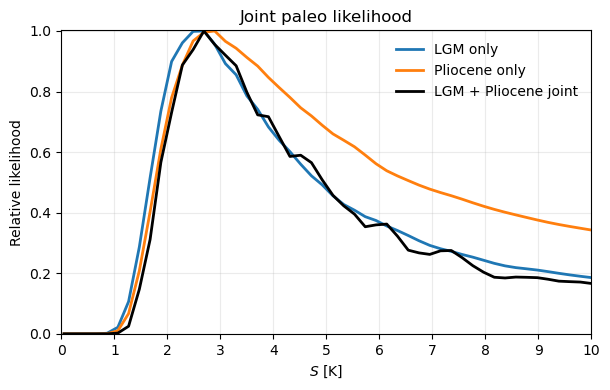

In [85]:
L_lgm_joint = []
L_plio_joint = []
L_paleo_joint = []

for S in S_like_grid:
    l_rev = -f2x_rev / S

    ## LGM residual likelihood
    N_lgm_pred = (
        f_other_lgm_rev
        - 0.57 * f2x_rev
        - t_lgm_rev * (dl_lgm_rev - l_rev / (1 + zeta_rev))
    )

    p_lgm = norm.pdf(
        coop_REVISED["mu_N_LGM"],
        loc=N_lgm_pred,
        scale=coop_REVISED["sig_N_LGM"],
    )

    ## Pliocene residual likelihood
    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev

    N_plio_pred = (
        f_plio_co2_rev * (1 + fch4_rev)
        + f_plio_nonghg_rev
        + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )

    p_plio = norm.pdf(
        coop_REVISED["mu_N_plio"],
        loc=N_plio_pred,
        scale=coop_REVISED["sig_N_plio"],
    )

    ## marginal and joint likelihoods
    L_lgm_joint.append(np.nanmean(p_lgm))
    L_plio_joint.append(np.nanmean(p_plio))
    L_paleo_joint.append(np.nanmean(p_lgm * p_plio))

L_lgm_joint = np.asarray(L_lgm_joint)
L_plio_joint = np.asarray(L_plio_joint)
L_paleo_joint = np.asarray(L_paleo_joint)

L_lgm_joint = L_lgm_joint / np.nanmax(L_lgm_joint)
L_plio_joint = L_plio_joint / np.nanmax(L_plio_joint)
L_paleo_joint = L_paleo_joint / np.nanmax(L_paleo_joint)

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=100)

ax.plot(S_like_grid, L_lgm_joint, label="LGM only", lw=2)
ax.plot(S_like_grid, L_plio_joint, label="Pliocene only", lw=2)
ax.plot(S_like_grid, L_paleo_joint, label="LGM + Pliocene joint", lw=2, color="k")

ax.set_xlabel("$S$ [K]")
ax.set_ylabel("Relative likelihood")
ax.set_title("Joint paleo likelihood")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

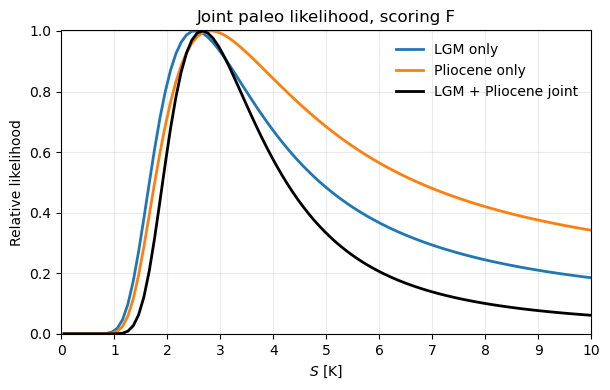

In [90]:
L_lgm_joint = []
L_plio_joint = []
L_paleo_joint = []

for S in S_like_grid:
    l_rev = -f2x_rev / S

    ## lgm: score F_other_LGM, ignoring N
    f_other_lgm_rev_pred = -(
        -0.57 * f2x_rev
        + t_lgm_rev * (l_rev / (1 + zeta_rev) - dl_lgm_rev)
    )

    p_lgm = norm.pdf(
        coop_REVISED["mu_F_other_LGM"],
        loc=f_other_lgm_rev_pred,
        scale=coop_REVISED["sig_F_other_LGM"],
    )

    ## pliocene: score F_plio_nonGHG, ignoring N
    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev

    f_plio_nonghg_rev_pred = -(
        f_plio_co2_rev * (1 + fch4_rev)
        + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )

    p_plio = norm.pdf(
        coop_REVISED["mu_F_plio_nonGHG"],
        loc=f_plio_nonghg_rev_pred,
        scale=coop_REVISED["sig_F_plio_nonGHG"],
    )

    ## marginal and joint likelihoods
    L_lgm_joint.append(np.nanmean(p_lgm))
    L_plio_joint.append(np.nanmean(p_plio))
    L_paleo_joint.append(np.nanmean(p_lgm * p_plio))

L_lgm_joint = np.asarray(L_lgm_joint)
L_plio_joint = np.asarray(L_plio_joint)
L_paleo_joint = np.asarray(L_paleo_joint)

L_lgm_joint = L_lgm_joint / np.nanmax(L_lgm_joint)
L_plio_joint = L_plio_joint / np.nanmax(L_plio_joint)
L_paleo_joint = L_paleo_joint / np.nanmax(L_paleo_joint)

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=100)

ax.plot(S_like_grid, L_lgm_joint, label="LGM only", lw=2)
ax.plot(S_like_grid, L_plio_joint, label="Pliocene only", lw=2)
ax.plot(S_like_grid, L_paleo_joint, label="LGM + Pliocene joint", lw=2, color="k")

ax.set_xlabel("$S$ [K]")
ax.set_ylabel("Relative likelihood")
ax.set_title("Joint paleo likelihood, scoring F")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

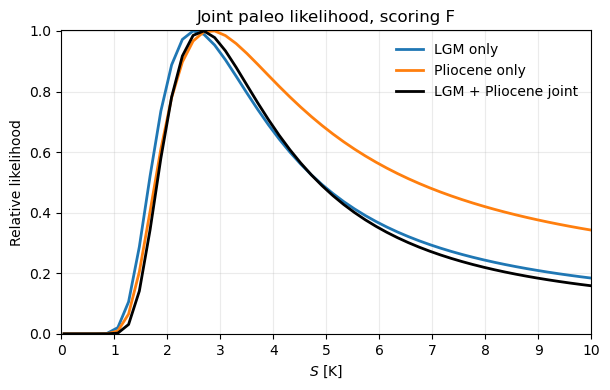

In [87]:
L_lgm_joint = []
L_plio_joint = []
L_paleo_joint = []

for S in S_like_grid:
    l_rev = -f2x_rev / S

    ## lgm: score F_other_LGM, ignoring N
    f_other_lgm_rev_pred = -(
        -0.57 * f2x_rev
        + t_lgm_rev * (l_rev / (1 + zeta_rev) - dl_lgm_rev)
    )

    p_lgm = norm.pdf(
        coop_REVISED["mu_F_other_LGM"],
        loc=f_other_lgm_rev_pred,
        scale=coop_REVISED["sig_F_other_LGM"],
    )

    ## pliocene: score F_plio_nonGHG, ignoring N
    f_plio_co2_rev = np.log(co2_plio_rev / 284) / np.log(2) * f2x_rev

    f_plio_nonghg_rev_pred = -(
        f_plio_co2_rev * (1 + fch4_rev)
        + t_plio_rev * (l_rev / (1 + zeta_rev) - dl_plio_rev)
    )

    p_plio = norm.pdf(
        coop_REVISED["mu_F_plio_nonGHG"],
        loc=f_plio_nonghg_rev_pred,
        scale=coop_REVISED["sig_F_plio_nonGHG"],
    )

    ## marginal and joint likelihoods
    L_lgm_joint.append(np.nanmean(p_lgm))
    L_plio_joint.append(np.nanmean(p_plio))
    L_paleo_joint.append(np.nanmean(p_lgm * p_plio))

L_lgm_joint = np.asarray(L_lgm_joint)
L_plio_joint = np.asarray(L_plio_joint)
L_paleo_joint = np.asarray(L_paleo_joint)

L_lgm_joint = L_lgm_joint / np.nanmax(L_lgm_joint)
L_plio_joint = L_plio_joint / np.nanmax(L_plio_joint)
L_paleo_joint = L_paleo_joint / np.nanmax(L_paleo_joint)

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=100)

ax.plot(S_like_grid, L_lgm_joint, label="LGM only", lw=2)
ax.plot(S_like_grid, L_plio_joint, label="Pliocene only", lw=2)
ax.plot(S_like_grid, L_paleo_joint, label="LGM + Pliocene joint", lw=2, color="k")

ax.set_xlabel("$S$ [K]")
ax.set_ylabel("Relative likelihood")
ax.set_title("Joint paleo likelihood, scoring F")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(-0.002, 1.002)
plt.xlim(0, S_like_grid.max())
plt.xticks(np.arange(11))
plt.tight_layout()
plt.show()

# PDFs

In [95]:
vars_show = [
    "S"]#, "l", "dlambda", "dlambda_LGM", "dlambda_plio",
    # "T_LGM", "T_plio", "F_other_LGM", "F_plio_nonGHG",
# ]

coopREV_Nresid_fit_UL.draws_pd(vars=vars_show).quantile(
    [0.05, 0.17, 0.50, 0.83, 0.95]
).T.round(2)

,0.05,0.17,0.50,0.83,0.95
S,2.47,2.8,3.4,4.29,5.25


In [94]:
coopREV_fit_UL.draws_pd(vars=vars_show).quantile(
    [0.05, 0.17, 0.50, 0.83, 0.95]
).T.round(2)

,0.05,0.17,0.50,0.83,0.95
S,2.37,2.68,3.23,4.02,4.86


In [97]:
coopREV_Nresid_fit_US.draws_pd(vars=vars_show).quantile(
    [0.05, 0.17, 0.50, 0.83, 0.95]
).T.round(2)

,0.05,0.17,0.50,0.83,0.95
S,2.65,3.05,3.82,5.07,6.67


In [96]:
coopREV_fit_US.draws_pd(vars=vars_show).quantile(
    [0.05, 0.17, 0.50, 0.83, 0.95]
).T.round(2)

,0.05,0.17,0.50,0.83,0.95
S,2.54,2.9,3.57,4.61,5.84


,p05,p17,p50,p83,p95
case,,,,,
SW20 Original (Unif. $\lambda$),2.22,2.55,3.13,3.95,4.78
Prelim. Revised,2.47,2.80,3.40,4.29,5.25


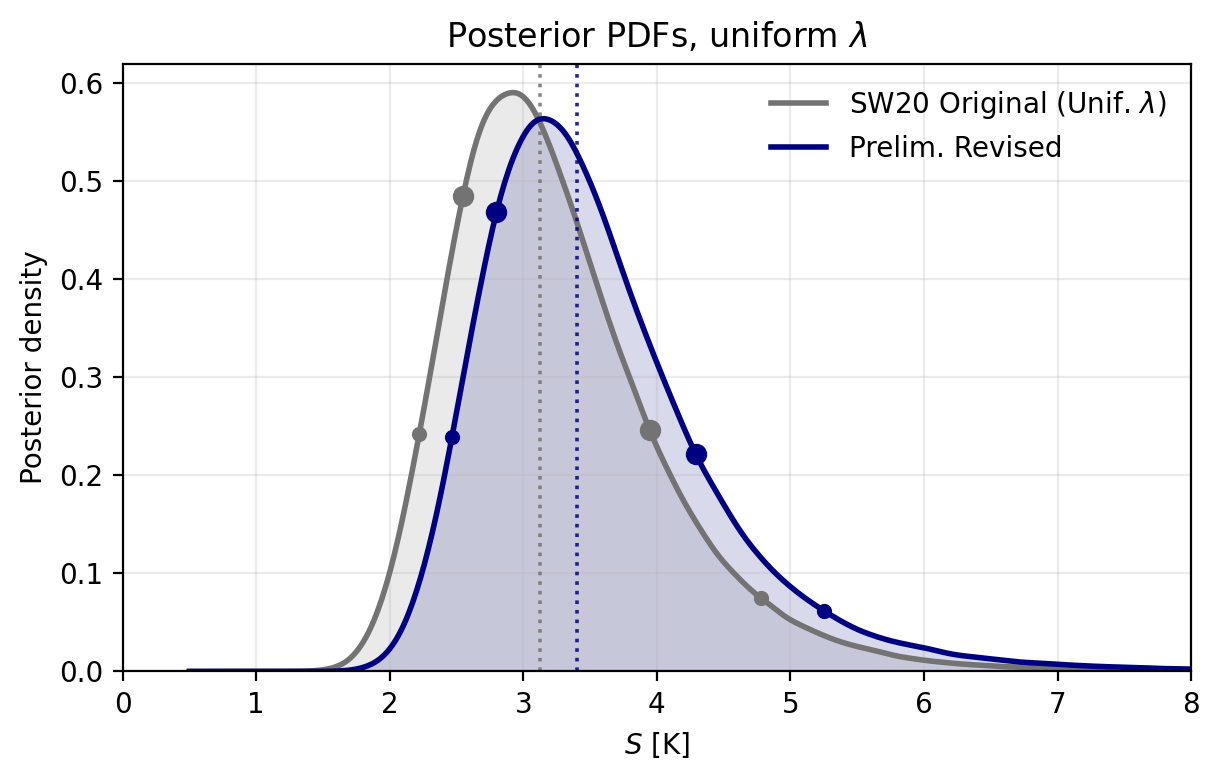

In [82]:
S_grid = np.linspace(0.5, 8, 500)

percentile_rows = []

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=200)

for S, lbl, color in [
    (sw20_S_UL, "SW20 Original (Unif. $\\lambda$)", "0.45"),
    (coopREV_Nresid_S_UL, "Prelim. Revised", "navy"),
]:
    S = np.asarray(S).ravel()
    S = S[np.isfinite(S)]

    kde = gaussian_kde(S, bw_method=0.1)
    pdf = kde(S_grid)

    pcts = np.percentile(S, [5, 17, 50, 83, 95])
    pct_pdf = kde(pcts)

    percentile_rows.append(
        {
            "case": lbl,
            "p05": pcts[0],
            "p17": pcts[1],
            "p50": pcts[2],
            "p83": pcts[3],
            "p95": pcts[4],
        }
    )

    ax.plot(S_grid, pdf, lw=2, color=color, label=lbl)
    ax.fill_between(S_grid, pdf, alpha=0.15, color=color)

    ## 5-95 small dots
    ax.scatter(
        pcts[[0, 4]],
        pct_pdf[[0, 4]],
        s=20,
        color=color,
        zorder=5,
    )

    ## 17-83 larger dots
    ax.scatter(
        pcts[[1, 3]],
        pct_pdf[[1, 3]],
        s=45,
        color=color,
        zorder=6,
    )

    ## median
    ax.axvline(
        pcts[2],
        color=color,
        ls=":",
        lw=1.3,
        alpha=0.85,
    )

percentile_table = pd.DataFrame(percentile_rows).set_index("case")
display(percentile_table.round(2))

ax.set_xlabel("$S$ [K]")
ax.set_ylabel("Posterior density")
ax.set_title("Posterior PDFs, uniform $\\lambda$")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.ylim(bottom=0)
plt.xlim(0, S_grid.max())
plt.xticks(np.arange(9))
plt.tight_layout()
plt.show()

<!-- ENERGY_BUDGET_EQUATIONS_SINGLE_CELL -->

## Energy-Budget Likelihood Equations

Using the signed feedback convention in the Stan code:

$$
\lambda \equiv -\frac{F_{2\times\mathrm{CO}_2}}{S}
$$

<!-- HISTORICAL_PARAMETER_TABLE -->

### Historical Parameter Values

<table>
  <thead>
    <tr>
      <th rowspan="2">Parameter</th>
      <th colspan="3">SW20 ($\overline{2006\text{–}2018}$ vs. $\overline{1861\text{–}1880}$)</th>
      <th colspan="3">Revision ($\overline{2006\text{–}2024}$ vs. $\overline{1850\text{–}1900}$)</th>
    </tr>
    <tr>
      <th>Median</th>
      <th>$1\sigma$</th>
      <th>5-95%</th>
      <th>Median</th>
      <th>$1\sigma$</th>
      <th>5-95%</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>T</td>
      <td>1.03</td>
      <td>0.09</td>
      <td>0.89 to 1.17</td>
      <td>1.08</td>
      <td>0.11</td>
      <td>0.90 to 1.26</td>
    </tr>
    <tr>
      <td>N</td>
      <td>0.60</td>
      <td>0.18</td>
      <td>0.30 to 0.90</td>
      <td>0.71</td>
      <td>0.20</td>
      <td>0.38 to 1.04</td>
    </tr>
    <tr>
      <td>F</td>
      <td>1.83</td>
      <td>skewed</td> <!-- !-1.13 / +0.53 -->
      <td>-0.03 to 2.71</td>
      <td>2.65</td>
      <td>0.41</td>
      <td>1.98 to 3.32</td>
    </tr>
    <tr>
      <td>$\Delta \lambda$</td>
      <td>0.50</td>
      <td>0.30</td>
      <td>0.00 to 1.00</td>
      <td>0.62</td>
      <td>0.33</td>
      <td>0.08 to 1.16</td>
    </tr>
  </tbody>
</table>

For symmetric parameters, the 5-95% range is median +/- 1.645 sigma. SW20 historical F uses the asymmetric split-normal uncertainty implemented in the likelihood code.

### Process

**SW20**

$$
\lambda \sim \mathcal{N}\left(\mu_{\lambda,\mathrm{SW20}},\sigma_{\lambda,\mathrm{SW20}}\right)
$$

**Cooper full revision**

$$
\lambda \sim \mathcal{N}\left(\mu_{\lambda,\mathrm{Cooper}},\sigma_{\lambda,\mathrm{Cooper}}\right)
$$

### Historical

**SW20**

$$
\Delta T_{\mathrm{hist}}
= -\frac{\Delta F_{\mathrm{hist}} - \Delta N_{\mathrm{hist}}}
{\lambda - \Delta\lambda_{\mathrm{hist}}}
$$

**Cooper full revision**

$$
\Delta N_{\mathrm{hist}}
= \Delta F_{\mathrm{hist}}
+ 
\left(\lambda - \Delta\lambda_{\mathrm{hist}}\right)
\Delta T_{\mathrm{hist}}
$$

### Last Glacial Maximum

**SW20**

$$
\Delta T_{\mathrm{LGM}}
=
\frac{-(-
0.57\Delta F_{2\times\mathrm{CO}_2}
+
\Delta F_{\mathrm{NonCO_2,LGM}})
}{
\frac{\lambda}{1+\zeta}
+
\frac{\alpha}{2}\Delta T_{\mathrm{LGM}}
}
$$

**Cooper full revision**
<!-- 
$$
\Delta N_{\mathrm{LGM}}
=
\left(-0.57\Delta F_{\mathrm{2xCO}_2}
+ \Delta F_{\mathrm{NonCO}_2,\mathrm{LGM}}\right)
+
\left(
\frac{\lambda}{1+\zeta}
- \Delta\lambda_{\mathrm{LGM}}
\right)
\Delta T_{\mathrm{LGM}}
$$ -->

$$
\Delta N_{\mathrm{LGM}}
=
\left(-0.57\Delta F_{\mathrm{2xCO}_2}
+ \Delta F_{\mathrm{NonCO}_2,\mathrm{LGM}}\right)
+
\left(
\lambda - \Delta\lambda_{\mathrm{LGM}}
\right)
\Delta T_{\mathrm{LGM}}
$$

where

$$
\Delta F_{\mathrm{CO}_2,\mathrm{LGM}}
\equiv -0.57\,F_{2\times\mathrm{CO}_2}.
$$

For an equilibrated LGM budget,

$$
\Delta N_{\mathrm{LGM}} \approx 0.
$$

### Pliocene

with

$$
\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
= \frac{\log\left(C_{\mathrm{Plio}}/284\right)}{\log 2}\,
F_{2\times\mathrm{CO}_2}
$$

**SW20**

$$
\Delta T_{\mathrm{Plio}}
= \frac{-\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
\left(1 + f_{\mathrm{CH}_4}\right)
\left(1 + f_{\mathrm{ESS}}\right)}
{\lambda/(1+\zeta)}
$$

**Cooper full revision**

<!-- $$
\Delta N_{\mathrm{Plio}}
=
\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
\left(1 + f_{\mathrm{CH}_4}\right)
+ \Delta F_{\mathrm{NonGHG},\mathrm{Plio}}
+ 
\left(
\frac{\lambda}{1+\zeta}
- \Delta\lambda_{\mathrm{Plio}}
\right)
\Delta T_{\mathrm{Plio}}
$$ -->

$$
\Delta N_{\mathrm{Plio}}
=
\Delta F_{\mathrm{CO}_2,\mathrm{Plio}}
\left(1 + f_{\mathrm{CH}_4}\right)
+ \Delta F_{\mathrm{NonGHG},\mathrm{Plio}}
+ 
\left(
\lambda - \Delta\lambda_{\mathrm{Plio}}
\right)
\Delta T_{\mathrm{Plio}}
$$

For an equilibrated Pliocene budget,

$$
\Delta N_{\mathrm{Plio}} \approx 0.
$$

In [23]:
## LGM detailed forcing parameter reference
#SW20 mu
lgm_ice = -3.2
lgm_veg = -1.1
lgm_aer = -1.0
lgm_n2o = -0.28
lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

## Revision mu
# lgm_ice = (-3.2 - 2.1)/2 # reduction in forcing: Paleocalibr CESM2 and CESM1.2
# print(lgm_ice)
lgm_ice = -2.65
lgm_veg = -0.5 # -1.1; look at Pliocene veg forcing; significant nonlocal offsets
lgm_aer = -0.5 #-1.0
# lgm_n2o = -0.28
# lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

## Revised 1sig
sig_ice = 0.85*1.5 #T20 spread from PMIP3 and PMIP2 using APRP
sig_veg = 0.57*1.5 # 50% increase
# sig_dust = 1. #0.94 kohler, 1.0 SW20
sig_dust = 1.46 # mahowald
sig_n2o = 0.10
sig_ch4 = 0.05
sig_nonco2 = (sig_ice**2 + sig_veg**2 + sig_dust**2 + sig_ch4**2 + sig_n2o**2)**0.5
sig_nonco2

-6.150000000000001
-4.5


2.121497112889857

In [14]:
## sw20 1sig
sig_ice_sw20 = 0.90 # includes land ice (0.63) snow cover (0.58) and sea level (0.29)
sig_veg_sw20 = 0.57 # 50% increase
# sig_dust = 1. #0.94 kohler, 1.0 SW20
sig_dust_sw20 = 0.94 # mahowald
sig_n2o_sw20 = 0.10
sig_ch4_sw20 = 0.05
sig_nonco2_sw20 = (sig_ice_sw20**2 + sig_veg_sw20**2 + 
                   sig_dust_sw20**2 + sig_ch4_sw20**2 + sig_n2o_sw20**2)**0.5
sig_nonco2_sw20

1.4251315728731855

In [83]:
## table of lgm values
import pandas as pd

## component values from the reference cell above
lgm_components_sw20 = {
    "Delta F_N2O": -0.28,
    "Delta F_CH4": -0.57,
    "Delta F_ice": -3.20,
    "Delta F_veg": -1.10,
    "Delta F_aer": -1.00,
}

lgm_components_rev = {
    "Delta F_N2O": -0.28,
    "Delta F_CH4": -0.57,
    "Delta F_ice": -2.65,
    "Delta F_veg": -0.50,
    "Delta F_aer": -0.50,
}

lgm_component_sig_sw20 = {
    "Delta F_N2O": 0.10,
    "Delta F_CH4": 0.05,
    "Delta F_ice": 0.90,
    "Delta F_veg": 0.57,
    "Delta F_aer": 0.94,
    "Additional Delta F": 1.40,
}

lgm_component_sig_rev = {
    "Delta F_N2O": 0.10,
    "Delta F_CH4": 0.05,
    "Delta F_ice": 0.85 * 1.5,
    "Delta F_veg": 0.57 * 1.5,
    "Delta F_aer": 1.46,
}

lgm_nonco2_sw20_mu = sum(lgm_components_sw20.values())
lgm_nonco2_rev_mu = sum(lgm_components_rev.values())
lgm_nonco2_sw20_sig = np.sqrt(np.sum(np.square(list(lgm_component_sig_sw20.values()))))
lgm_nonco2_rev_sig = np.sqrt(np.sum(np.square(list(lgm_component_sig_rev.values()))))

## use the likelihood monte carlo draws above if they exist; otherwise make local draws
_lgm_table_rng = np.random.default_rng(20260609)
try:
    _f2x_sw = np.asarray(f2x_sw, dtype=float)
except NameError:
    _f2x_sw = _lgm_table_rng.normal(
        SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"], 50000
    )

try:
    _f2x_rev = np.asarray(f2x_rev, dtype=float)
except NameError:
    _f2x_rev = _lgm_table_rng.normal(
        coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"], 50000
    )

_f_nonco2_sw = _lgm_table_rng.normal(
    lgm_nonco2_sw20_mu, lgm_nonco2_sw20_sig, len(_f2x_sw)
)

try:
    _f_nonco2_rev = np.asarray(f_other_lgm_rev, dtype=float)
except NameError:
    _f_nonco2_rev = _lgm_table_rng.normal(
        coop_REVISED["mu_F_other_LGM"], coop_REVISED["sig_F_other_LGM"], len(_f2x_rev)
    )

_f_co2_sw = -0.57 * _f2x_sw
_f_co2_rev = -0.57 * _f2x_rev
_f_total_sw = _f_co2_sw + _f_nonco2_sw
_f_total_rev = _f_co2_rev + _f_nonco2_rev

lgm_rows = [
    "Delta T",
    "Delta lambda",
    "alpha",
    "zeta",
    "Delta F total",
    "Delta F_CO2",
    "Delta F_nonCO2",
    "Delta F_N2O",
    "Delta F_CH4",
    "Delta F_ice",
    "Delta F_veg",
    "Delta F_aer",
    "Additional Delta F",
    "N_LGM",
]

lgm_row_labels = {
    "Delta T": r"$\Delta T$",
    "Delta lambda": r"$\Delta \lambda$",
    "alpha": r"$\alpha$",
    "zeta": r"$\zeta$",
    "Delta F total": r"$\Delta F_{\mathrm{total}}$",
    "Delta F_CO2": r"$\Delta F_{\mathrm{CO2}}$",
    "Delta F_nonCO2": r"$\Delta F_{\mathrm{nonCO2}}$",
    "Delta F_N2O": r"$\Delta F_{\mathrm{N2O}}$",
    "Delta F_CH4": r"$\Delta F_{\mathrm{CH4}}$",
    "Delta F_ice": r"$\Delta F_{\mathrm{ice}}$",
    "Delta F_veg": r"$\Delta F_{\mathrm{veg}}$",
    "Delta F_aer": r"$\Delta F_{\mathrm{aer}}$",
    "Additional Delta F": r"Inflate $\Delta F$",
    "N_LGM": r"$N_{\mathrm{LGM}}$",
}

lgm_table_values = {
    "Delta T": {
        ("SW20", "μ"): SW20_BASE["mu_T_LGM"],
        ("SW20", "1sigma"): SW20_BASE["sig_T_LGM"],
        ("Revised", "μ"): coop_REVISED["mu_T_LGM"],
        ("Revised", "1sigma"): coop_REVISED["sig_T_LGM"],
    },
    "Delta lambda": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): np.nan,
        ("Revised", "μ"): coop_REVISED["mu_dlambda_LGM"],
        ("Revised", "1sigma"): coop_REVISED["sig_dlambda_LGM"],
    },
    "alpha": {
        ("SW20", "μ"): SW20_BASE["mu_alpha"],
        ("SW20", "1sigma"): SW20_BASE["sig_alpha"],
        ("Revised", "μ"): np.nan,
        ("Revised", "1sigma"): np.nan,
    },
    "zeta": {
        ("SW20", "μ"): SW20_BASE["mu_zeta"],
        ("SW20", "1sigma"): SW20_BASE["sig_zeta"],
        ("Revised", "μ"): coop_REVISED["mu_zeta"],
        ("Revised", "1sigma"): coop_REVISED["sig_zeta"],
    },
    "Delta F total": {
        ("SW20", "μ"): -0.57 * SW20_BASE["mu_F2xCO2"] + lgm_nonco2_sw20_mu,
        ("SW20", "1sigma"): np.nanstd(_f_total_sw, ddof=1),
        ("Revised", "μ"): -0.57 * coop_REVISED["mu_F2xCO2"] + lgm_nonco2_rev_mu,
        ("Revised", "1sigma"): np.nanstd(_f_total_rev, ddof=1),
    },
    "Delta F_CO2": {
        ("SW20", "μ"): -0.57 * SW20_BASE["mu_F2xCO2"],
        ("SW20", "1sigma"): np.nanstd(_f_co2_sw, ddof=1),
        ("Revised", "μ"): -0.57 * coop_REVISED["mu_F2xCO2"],
        ("Revised", "1sigma"): np.nanstd(_f_co2_rev, ddof=1),
    },
    "Delta F_nonCO2": {
        ("SW20", "μ"): lgm_nonco2_sw20_mu,
        ("SW20", "1sigma"): lgm_nonco2_sw20_sig,
        ("Revised", "μ"): lgm_nonco2_rev_mu,
        ("Revised", "1sigma"): np.nanstd(_f_nonco2_rev, ddof=1),
    },
    "Additional Delta F": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): lgm_component_sig_sw20["Additional Delta F"],
        ("Revised", "μ"): np.nan,
        ("Revised", "1sigma"): np.nan,
    },
    "N_LGM": {
        ("SW20", "μ"): 0.0,
        ("SW20", "1sigma"): 0.0,
        ("Revised", "μ"): coop_REVISED["mu_N_LGM"],
        ("Revised", "1sigma"): coop_REVISED["sig_N_LGM"],
    },
}

for _row in ["Delta F_N2O", "Delta F_CH4", "Delta F_ice", "Delta F_veg", "Delta F_aer"]:
    lgm_table_values[_row] = {
        ("SW20", "μ"): lgm_components_sw20[_row],
        ("SW20", "1sigma"): lgm_component_sig_sw20[_row],
        ("Revised", "μ"): lgm_components_rev[_row],
        ("Revised", "1sigma"): lgm_component_sig_rev[_row],
    }

lgm_parameter_table = pd.DataFrame.from_dict(lgm_table_values, orient="index")
lgm_parameter_table = lgm_parameter_table.reindex(lgm_rows)
lgm_parameter_table = lgm_parameter_table.rename(index=lgm_row_labels)
lgm_parameter_table.columns = pd.MultiIndex.from_tuples(lgm_parameter_table.columns)
lgm_parameter_table = lgm_parameter_table[["SW20", "Revised"]]

lgm_parameter_table.style.format("{:.2f}", na_rep="")


In [84]:
## table of pliocene values
import pandas as pd

_plio_table_rng = np.random.default_rng(20260609)
_plio_table_n = 50000

try:
    _f2x_sw = np.asarray(f2x_sw, dtype=float)
except NameError:
    _f2x_sw = _plio_table_rng.normal(
        SW20_BASE["mu_F2xCO2"], SW20_BASE["sig_F2xCO2"], _plio_table_n
    )

try:
    _f2x_rev = np.asarray(f2x_rev, dtype=float)
except NameError:
    _f2x_rev = _plio_table_rng.normal(
        coop_REVISED["mu_F2xCO2"], coop_REVISED["sig_F2xCO2"], _plio_table_n
    )

try:
    _co2_plio_sw = np.asarray(co2_plio_sw, dtype=float)
except NameError:
    _co2_plio_sw = _plio_table_rng.normal(
        SW20_BASE["mu_CO2_plio"], SW20_BASE["sig_CO2_plio"], len(_f2x_sw)
    )

try:
    _co2_plio_rev = np.asarray(co2_plio_rev, dtype=float)
except NameError:
    _co2_plio_rev = _plio_table_rng.normal(
        coop_REVISED["mu_CO2_plio"], coop_REVISED["sig_CO2_plio"], len(_f2x_rev)
    )

try:
    _fch4_rev = np.asarray(fch4_rev, dtype=float)
except NameError:
    _fch4_rev = _plio_table_rng.normal(
        coop_REVISED["mu_fCH4"], coop_REVISED["sig_fCH4"], len(_f2x_rev)
    )

try:
    _f_plio_nonghg_rev = np.asarray(f_plio_nonghg_rev, dtype=float)
except NameError:
    _f_plio_nonghg_rev = _plio_table_rng.normal(
        coop_REVISED["mu_F_plio_nonGHG"],
        coop_REVISED["sig_F_plio_nonGHG"],
        len(_f2x_rev),
    )

_f_plio_co2_sw = np.log(_co2_plio_sw / 284) / np.log(2) * _f2x_sw
_f_plio_co2_rev = np.log(_co2_plio_rev / 284) / np.log(2) * _f2x_rev
_f_plio_total_rev = _f_plio_co2_rev * (1 + _fch4_rev) + _f_plio_nonghg_rev
_f_plio_ch4_rev = _f_plio_total_rev - _f_plio_co2_rev - _f_plio_nonghg_rev

plio_rows = [
    "Delta T",
    "Delta lambda",
    "f_CH4",
    "f_ESS",
    "zeta",
    "Delta F total",
    "CO2_ppm",
    "Delta F_CO2",
    "Delta F_CH4",
    "Delta F_nonGHG",
    "N_plio",
]

plio_row_labels = {
    "Delta T": r"$\Delta T$",
    "Delta lambda": r"$\Delta \lambda$",
    "f_CH4": r"$f_{\mathrm{CH4}}$",
    "f_ESS": r"$f_{\mathrm{ESS}}$",
    "zeta": r"$\zeta$",
    "Delta F total": r"$\Delta F_{\mathrm{total}}$",
    "CO2_ppm": r"$\mathrm{CO2}$ [ppm]",
    "Delta F_CO2": r"$\Delta F_{\mathrm{CO2}}$",
    "Delta F_CH4": r"$\Delta F_{\mathrm{CH4}}$",
    "Delta F_nonGHG": r"$\Delta F_{\mathrm{nonGHG}}$",
    "N_plio": r"$N_{\mathrm{Plio}}$",
}

plio_table_values = {
    "Delta T": {
        ("SW20", "μ"): SW20_BASE["mu_T_plio"],
        ("SW20", "1sigma"): SW20_BASE["sig_T_plio"],
        ("Revised", "μ"): coop_REVISED["mu_T_plio"],
        ("Revised", "1sigma"): coop_REVISED["sig_T_plio"],
    },
    "Delta lambda": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): np.nan,
        ("Revised", "μ"): coop_REVISED["mu_dlambda_plio"],
        ("Revised", "1sigma"): coop_REVISED["sig_dlambda_plio"],
    },
    "f_CH4": {
        ("SW20", "μ"): SW20_BASE["mu_fCH4"],
        ("SW20", "1sigma"): SW20_BASE["sig_fCH4"],
        ("Revised", "μ"): coop_REVISED["mu_fCH4"],
        ("Revised", "1sigma"): coop_REVISED["sig_fCH4"],
    },
    "f_ESS": {
        ("SW20", "μ"): SW20_BASE["mu_fESS"],
        ("SW20", "1sigma"): SW20_BASE["sig_fESS"],
        ("Revised", "μ"): np.nan,
        ("Revised", "1sigma"): np.nan,
    },
    "zeta": {
        ("SW20", "μ"): SW20_BASE["mu_zeta"],
        ("SW20", "1sigma"): SW20_BASE["sig_zeta"],
        ("Revised", "μ"): coop_REVISED["mu_zeta"],
        ("Revised", "1sigma"): coop_REVISED["sig_zeta"],
    },
    "Delta F total": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): np.nan,
        ("Revised", "μ"): np.nanmean(_f_plio_total_rev),
        ("Revised", "1sigma"): np.nanstd(_f_plio_total_rev, ddof=1),
    },
    "CO2_ppm": {
        ("SW20", "μ"): SW20_BASE["mu_CO2_plio"],
        ("SW20", "1sigma"): SW20_BASE["sig_CO2_plio"],
        ("Revised", "μ"): coop_REVISED["mu_CO2_plio"],
        ("Revised", "1sigma"): coop_REVISED["sig_CO2_plio"],
    },
    "Delta F_CO2": {
        ("SW20", "μ"): np.nanmean(_f_plio_co2_sw),
        ("SW20", "1sigma"): np.nanstd(_f_plio_co2_sw, ddof=1),
        ("Revised", "μ"): np.nanmean(_f_plio_co2_rev),
        ("Revised", "1sigma"): np.nanstd(_f_plio_co2_rev, ddof=1),
    },
    "Delta F_CH4": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): np.nan,
        ("Revised", "μ"): np.nanmean(_f_plio_ch4_rev),
        ("Revised", "1sigma"): np.nanstd(_f_plio_ch4_rev, ddof=1),
    },
    "Delta F_nonGHG": {
        ("SW20", "μ"): np.nan,
        ("SW20", "1sigma"): np.nan,
        ("Revised", "μ"): coop_REVISED["mu_F_plio_nonGHG"],
        ("Revised", "1sigma"): coop_REVISED["sig_F_plio_nonGHG"],
    },
    "N_plio": {
        ("SW20", "μ"): 0.0,
        ("SW20", "1sigma"): 0.0,
        ("Revised", "μ"): coop_REVISED["mu_N_plio"],
        ("Revised", "1sigma"): coop_REVISED["sig_N_plio"],
    },
}

plio_parameter_table = pd.DataFrame.from_dict(plio_table_values, orient="index")
plio_parameter_table = plio_parameter_table.reindex(plio_rows)
plio_parameter_table = plio_parameter_table.rename(index=plio_row_labels)
plio_parameter_table.columns = pd.MultiIndex.from_tuples(plio_parameter_table.columns)
plio_parameter_table = plio_parameter_table[["SW20", "Revised"]]

plio_parameter_table.style.format("{:.2f}", na_rep="")


# Posterior predictive check

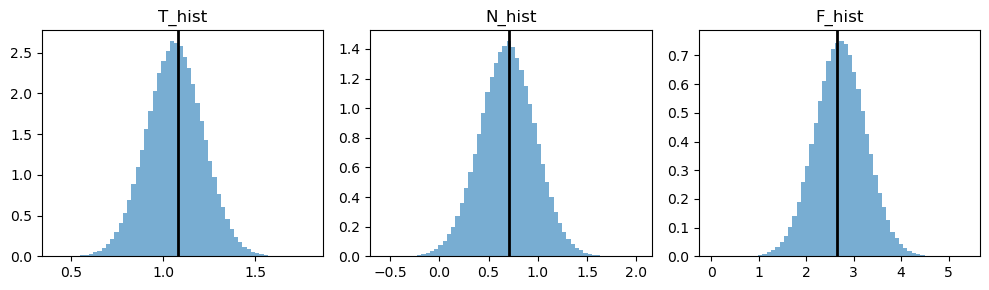

In [69]:
draws = coopREV_fit_UL.draws_pd()

rng = np.random.default_rng(0)

T_hist_rep = rng.normal(
    loc=draws["T_hist"],
    scale=coopREV_data_UL["sig_T_hist"],
)

N_hist_rep = rng.normal(
    loc=draws["N_hist"],
    scale=coopREV_data_UL["sig_N_hist"],
)

F_hist_rep = rng.normal(
    loc=draws["F_hist"],
    scale=coopREV_data_UL["sig_F_hist"],
)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].hist(T_hist_rep, bins=60, density=True, alpha=0.6)
axs[0].axvline(coopREV_data_UL["mu_T_hist"], color="k", lw=2)
axs[0].set_title("T_hist")

axs[1].hist(N_hist_rep, bins=60, density=True, alpha=0.6)
axs[1].axvline(coopREV_data_UL["mu_N_hist"], color="k", lw=2)
axs[1].set_title("N_hist")

axs[2].hist(F_hist_rep, bins=60, density=True, alpha=0.6)
axs[2].axvline(coopREV_data_UL["mu_F_hist"], color="k", lw=2)
axs[2].set_title("F_hist")

plt.tight_layout()
plt.show()

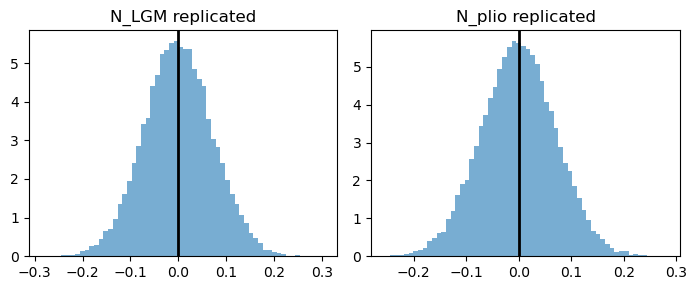

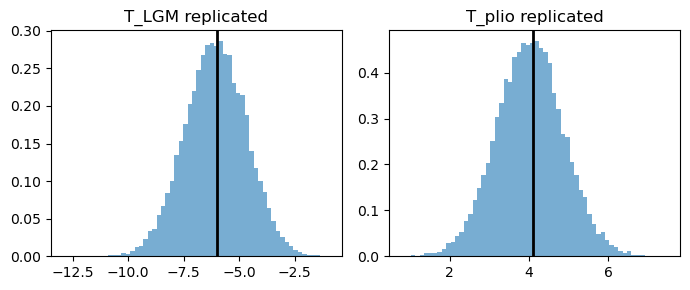

In [74]:
draws = coopREV_Nresid_fit_UL.draws_pd()
rng = np.random.default_rng(0)

T_LGM_rep = rng.normal(draws["T_LGM"], coopREV_data_UL["sig_T_LGM"])
N_LGM_rep = rng.normal(draws["N_LGM"], coopREV_data_UL["sig_N_LGM"])
T_plio_rep = rng.normal(draws["T_plio"], coopREV_data_UL["sig_T_plio"])
N_plio_rep = rng.normal(draws["N_plio"], coopREV_data_UL["sig_N_plio"])

fig, axs = plt.subplots(1, 2, figsize=(7, 3))

axs[0].hist(N_LGM_rep, bins=60, density=True, alpha=0.6)
axs[0].axvline(coopREV_data_UL["mu_N_LGM"], color="k", lw=2)
axs[0].set_title("N_LGM replicated")

axs[1].hist(N_plio_rep, bins=60, density=True, alpha=0.6)
axs[1].axvline(coopREV_data_UL["mu_N_plio"], color="k", lw=2)
axs[1].set_title("N_plio replicated")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(7, 3))

axs[0].hist(T_LGM_rep, bins=60, density=True, alpha=0.6)
axs[0].axvline(coopREV_data_UL["mu_T_LGM"], color="k", lw=2)
axs[0].set_title("T_LGM replicated")

axs[1].hist(T_plio_rep, bins=60, density=True, alpha=0.6)
axs[1].axvline(coopREV_data_UL["mu_T_plio"], color="k", lw=2)
axs[1].set_title("T_plio replicated")

plt.tight_layout()
plt.show()

In [75]:
p_N_LGM = np.mean(np.abs(N_LGM_rep - draws["N_LGM"]) >= np.abs(coopREV_data_UL["mu_N_LGM"] - draws["N_LGM"]))
p_N_plio = np.mean(np.abs(N_plio_rep - draws["N_plio"]) >= np.abs(coopREV_data_UL["mu_N_plio"] - draws["N_plio"]))

print(p_N_LGM, p_N_plio)

0.4948 0.49885
